# Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Выключение логгирования (для Prophet)
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

In [2]:
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
## make plots bigger
from pylab import rcParams
rcParams['figure.figsize'] = 15, 7

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# models
from tbats import TBATS
from prophet import Prophet
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

import time
from scipy import stats
from prophet.make_holidays import make_holidays_df
import itertools
from sklearn.model_selection import ParameterGrid

def plot_results(y_to_train,
                 y_to_test, y_forecast,
                 plot_conf_int=True,
                 left_bound=None, right_bound=None):

    plt.plot(y_to_train, label='train')
    plt.plot(y_to_test, label='test')
    plt.plot(y_to_test.index, y_forecast, label='prediction')

    if plot_conf_int:
        plt.fill_between(y_to_test.index,
                         left_bound, right_bound,
                         alpha=0.23, color='grey',
                         label='intervals')
    plt.legend()
    plt.show()

In [3]:
def get_grid_count(param_grid):
    """Подсчет комбинаций в гриде параметров"""
    n = 1
    for param, values in param_grid.items():
        n *= len(values)
    return n

# Prophet, SARIMAX, TBATS — модели для предсказания временных рядов

## 1. Задача

**Рассмотрим [датасет](https://www.kaggle.com/c/demand-forecasting-kernels-only/overview) с kaggle с соревнования по прогнозированию спроса на товары.**

In [4]:
data = pd.read_csv('train.csv', parse_dates=['date'])
print(data.shape)
data.head()

(913000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [5]:
store, item = 1, 1
data = data[(data['store'] == store) & (data['item'] == item)]
data = data.set_index('date')
data = data['sales']

In [6]:
data

date
2013-01-01    13
2013-01-02    11
2013-01-03    14
2013-01-04    13
2013-01-05    10
              ..
2017-12-27    14
2017-12-28    19
2017-12-29    15
2017-12-30    27
2017-12-31    23
Name: sales, Length: 1826, dtype: int64

## 2. Данные
**Разделим данные на train и test. test — данные за последний год.**

In [7]:
test_size = 365
data_train = data.iloc[: -test_size]
data_test  = data.iloc[-test_size:]

# data_train = data.iloc[-test_size*4: -test_size]

**Визуализируем данные**

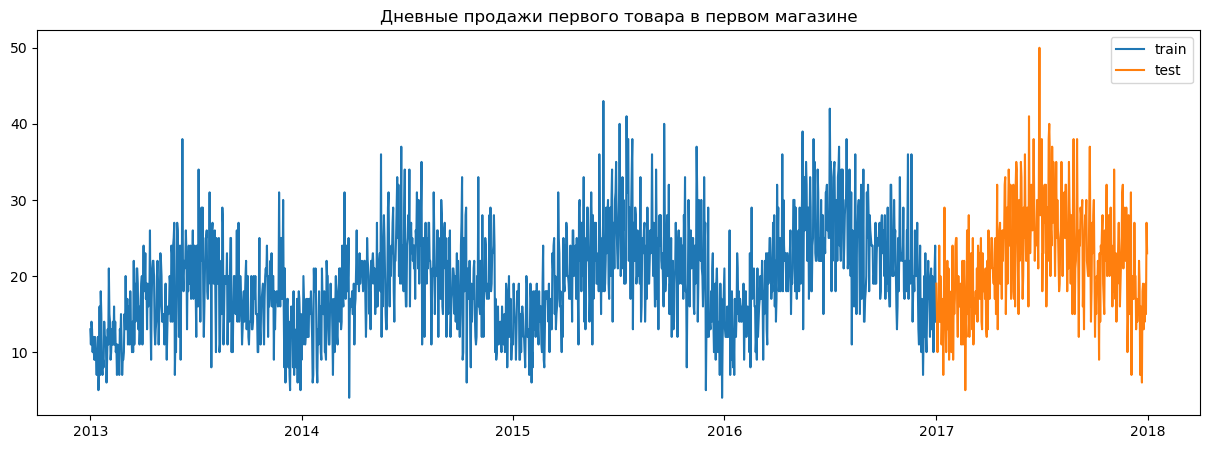

In [8]:
plt.figure(figsize=(15, 5))

plt.title('Дневные продажи первого товара в первом магазине')

# plt.plot(data_train[-test_size*2:-test_size], label='train')
plt.plot(data_train, label='train')
plt.plot(data_test,  label='test')
plt.legend()
plt.show()

**Некоторая недельная сезонность есть**

## 3. Метрики
- Зададим метрики качества моделей: MSE, MAE, MAPE. 
- Зададим функцию, которая будет вычислять метрики качества моделей и записывать их в таблицу.


- MAPE (Mean Absolute Percentage Error) поможет оценить, насколько близки прогнозы к фактическим значениям в процентном соотношении.
- MSE (Mean Squared Error) — для измерения среднеквадратичной ошибки между прогнозами и фактическими значениями. Это поможет понять среднюю ошибку прогноза в квадрате.
- MAE (Mean Absolute Error) — для оценки средней абсолютной ошибки между прогнозами и реальными значениями. Хорошо интерпретируется и проста в использовании.

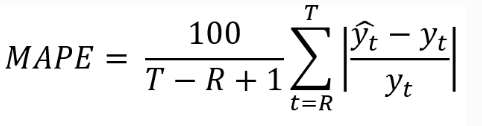

In [9]:
# MAPE
def mean_absolute_percentage_error(y_true, y_pred) -> float:
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [10]:
def add_method_comparison(method: str, y_true, y_forecast, time_fit=0.0, compare_table=None) -> pd.DataFrame:
    result_row = {
        'method':   method,
        "MSE":      mean_squared_error(y_true=y_true, y_pred=y_forecast),
        "MAE":      mean_absolute_error(y_true=y_true, y_pred=y_forecast),
        "MAPE":     mean_absolute_percentage_error(y_true=y_true, y_pred=y_forecast),
        'time_fit': round(time_fit, 2)
    }

    if compare_table is None:
        compare_table = pd.DataFrame([result_row])
    else:
        if method in list(compare_table['method']):
            compare_table = compare_table[compare_table['method'] != method]

        compare_table = pd.concat([compare_table, pd.DataFrame([result_row])])
        compare_table.index = np.arange(len(compare_table))
        
    return compare_table

In [11]:
# compare_table.drop(compare_table.index, inplace=True)

## 4. Prophet

### 4.1. Prophet

Prophet — модель для предсказания временных рядов, разработанная «Фейсбуком»*.

*Деятельность компании Meta Platforms Inc., которой принадлежит указаная соцсеть и сервис, признана экстремистской и запрещена на территории РФ.

In [12]:
prophet_train_df = pd.DataFrame(data_train)

prophet_train_df.columns = ['y']
prophet_train_df['ds'] = prophet_train_df.index

In [13]:
prophet_train_df

,y,ds
date,,
2013-01-01,13,2013-01-01
2013-01-02,11,2013-01-02
2013-01-03,14,2013-01-03
2013-01-04,13,2013-01-04
2013-01-05,10,2013-01-05
...,...,...
2016-12-27,10,2016-12-27
2016-12-28,16,2016-12-28
2016-12-29,21,2016-12-29


In [14]:
# Выключение логгирования (для Prophet)
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

In [15]:
%%time
prophet_model = Prophet( interval_width=0.95 )

time_start = time.time()
prophet_model.fit(prophet_train_df)
time_fit = time.time() - time_start

future = prophet_model.make_future_dataframe(
    periods=test_size, 
    include_history=False
)

y_prophet_forecast = prophet_model.predict(future)

17:03:35 - cmdstanpy - INFO - Chain [1] start processing
17:03:35 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 1.03 s
Wall time: 1.66 s


In [16]:
y_prophet_forecast.head(3)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-01,22.656356,12.842148,30.199680,22.656356,22.656356,-1.504734,-1.504734,-1.504734,3.723809,3.723809,3.723809,-5.228543,-5.228543,-5.228543,0.0,0.0,0.0,21.151622
1,2017-01-02,22.660401,4.057719,21.482723,22.660401,22.660401,-9.438694,-9.438694,-9.438694,-4.232952,-4.232952,-4.232952,-5.205742,-5.205742,-5.205742,0.0,0.0,0.0,13.221706
2,2017-01-03,22.664446,7.392179,23.796555,22.664446,22.664446,-6.836072,-6.836072,-6.836072,-1.636036,-1.636036,-1.636036,-5.200037,-5.200037,-5.200037,0.0,0.0,0.0,15.828373


Модель для каждой даты раскладывает своё предсказание на компоненты.

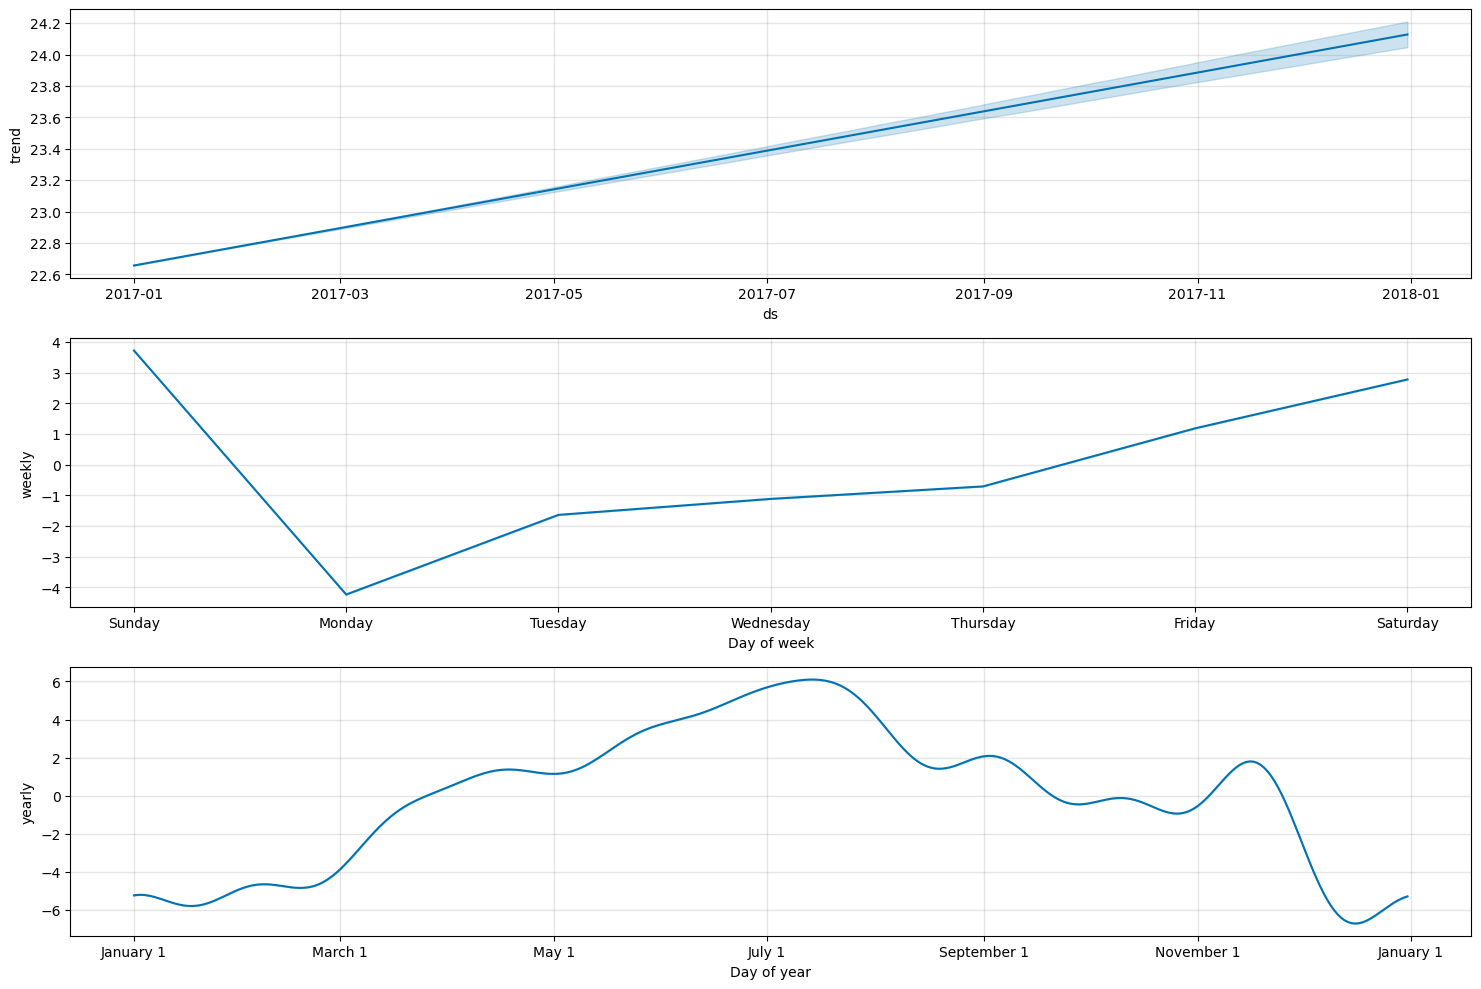

In [17]:
prophet_model.plot_components(y_prophet_forecast, figsize=(15, 10))
plt.show()

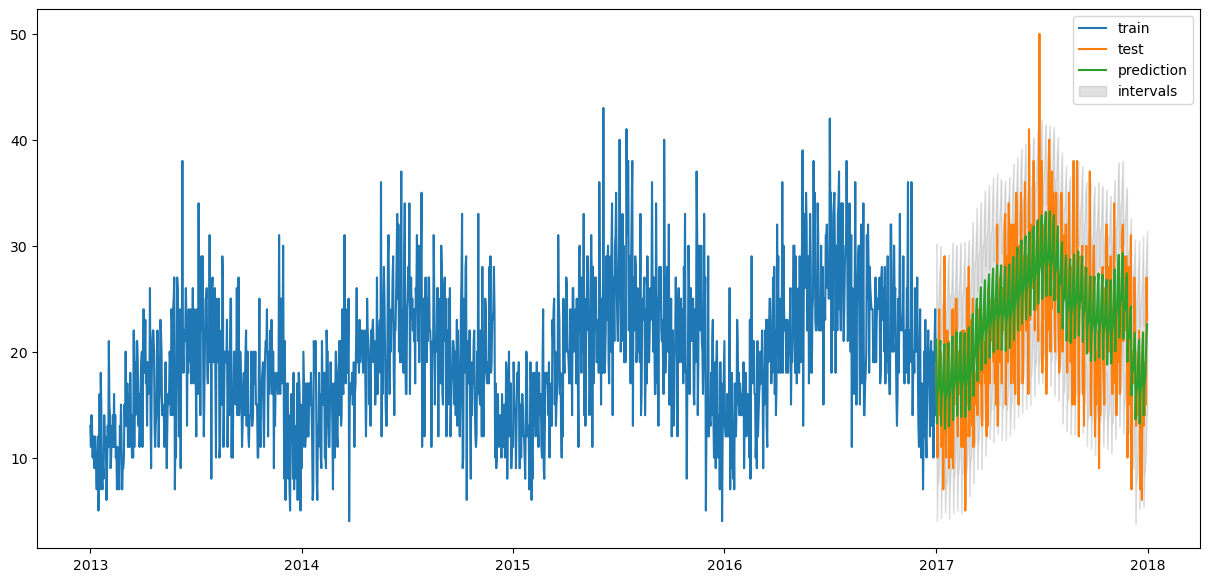

In [18]:
plot_results(
    data_train, data_test, y_prophet_forecast['yhat'], 
    plot_conf_int=True,
    left_bound=y_prophet_forecast['yhat_lower'], right_bound=y_prophet_forecast['yhat_upper']
)

In [19]:
compare_table = add_method_comparison(
    'Prophet', 
    data_test, 
    y_prophet_forecast['yhat'], 
    time_fit=time_fit,
    compare_table=None
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76


#### **Задание**
- Обучите модель Prophet с учётом праздников США — *Prophet + US holidays*.
- Преобразование Бокса — Кокса: обучите модель Prophet на преобразованном таргете — *Prophet*:
    - сделайте прямое преобразование над таргетом sps.boxcox(y);
    - потом сделайте обратное (нужно написать самостоятельно).

In [20]:
# print(data_train.index.min(), data_train.index.max())
# print(data_test.index.min(), data_test.index.max())

### 4.2. Prophet + US holidays

#### Метод `make_holidays_df`

In [21]:
if False:
    # 4.2. Prophet + US holidays
    
    # Создаем DataFrame с праздниками США
    years = range(data_train.index.min().year, data_train.index.max().year + 2)
    us_holidays = make_holidays_df(year_list=years, country='US')
    
    # us_holidays_main = ["Christmas Day", "New Year's Day", "Thanksgiving Day"]
    # us_holidays = us_holidays[ ~us_holidays['holiday'].isin( us_holidays_main ) ]
    
    print(us_holidays.shape)
    us_holidays.sort_values('holiday', ascending=True)

#### Встроенная функция `add_country_holidays`
- Здесь использую функцию **add_country_holidays**. Результаты с **make_holidays_df** получились немного хуже, чем с **add_country_holidays**

In [22]:
# Использую add_country_holidays. Результаты с make_holidays_df получились немного хуже, чем с add_country_holidays

# Обучение модели
prophet_model_holidays = Prophet(
    interval_width=0.95,
    # holidays=us_holidays,
)

# Встроенная функция add_country_holidays
prophet_model_holidays.add_country_holidays(country_name='US')

time_start = time.time()
prophet_model_holidays.fit(prophet_train_df)
time_fit = time.time() - time_start

# Прогноз
y_prophet_holidays_forecast = prophet_model_holidays.predict(future)
y_prophet_holidays_forecast.head(3)

17:03:37 - cmdstanpy - INFO - Chain [1] start processing
17:03:37 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Christmas Day (observed),...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-01,22.685088,13.975506,30.742525,22.685088,22.685088,0.0,0.0,0.0,0.0,...,3.717499,3.717499,3.717499,-5.365563,-5.365563,-5.365563,0.0,0.0,0.0,22.028173
1,2017-01-02,22.689281,5.472085,21.406821,22.689281,22.689281,0.0,0.0,0.0,0.0,...,-4.144154,-4.144154,-4.144154,-5.334951,-5.334951,-5.334951,0.0,0.0,0.0,13.210176
2,2017-01-03,22.693473,6.812950,24.343406,22.693473,22.693473,0.0,0.0,0.0,0.0,...,-1.637374,-1.637374,-1.637374,-5.320110,-5.320110,-5.320110,0.0,0.0,0.0,15.735990


In [23]:
# Список праздников
prophet_model_holidays.train_holiday_names

0                  New Year's Day
1                    Memorial Day
2                Independence Day
3                       Labor Day
4                    Veterans Day
5                Thanksgiving Day
6                   Christmas Day
7        Christmas Day (observed)
8      Martin Luther King Jr. Day
9           Washington's Birthday
10                   Columbus Day
11    Independence Day (observed)
dtype: object

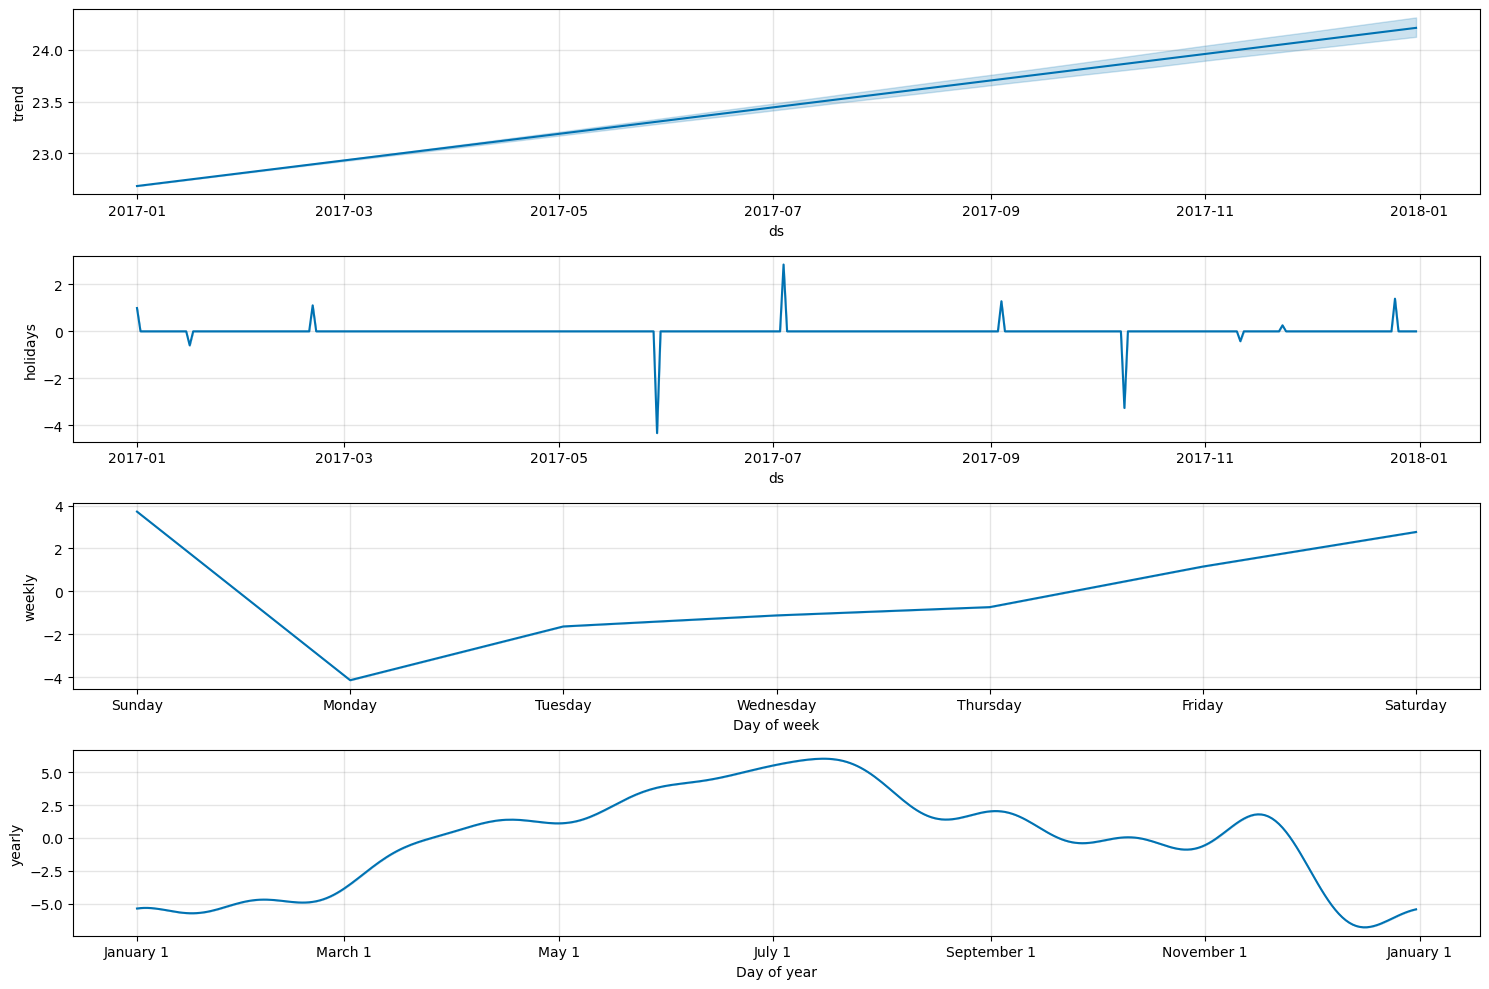

In [24]:
prophet_model_holidays.plot_components(y_prophet_holidays_forecast, figsize=(15, 10))
plt.show()

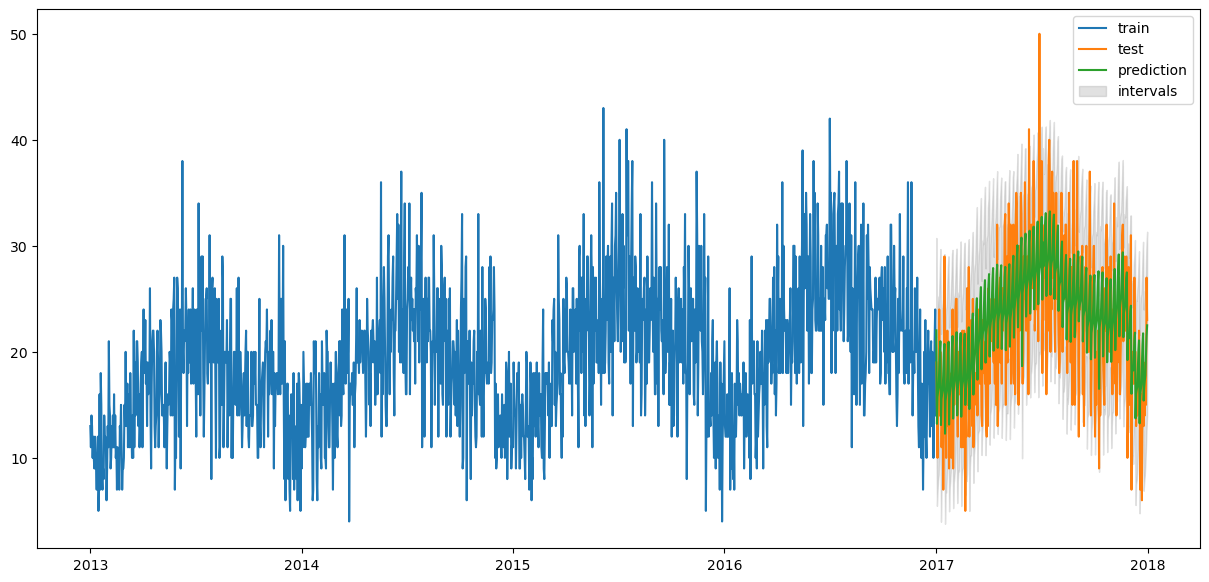

In [25]:
# Визуализация
plot_results(
    data_train, data_test, y_prophet_holidays_forecast['yhat'], 
    plot_conf_int=True,
    left_bound=y_prophet_holidays_forecast['yhat_lower'], right_bound=y_prophet_holidays_forecast['yhat_upper']
)

In [26]:
# Метрики
compare_table = add_method_comparison(
    'Prophet + Holidays', 
    data_test, 
    y_prophet_holidays_forecast['yhat'], 
    time_fit,
    compare_table
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32


### 4.3. Prophet. Преобразование Бокса — Кокса

In [27]:
# 4.3. Prophet. Преобразование Бокса — Кокса

# Прямое преобразование Бокса-Кокса
data_train_boxcox, lam = stats.boxcox(data_train + 1)  # +1 чтобы избежать нулей

# Подготавка данные для Prophet
prophet_train_boxcox_df = pd.DataFrame({
    'ds': data_train.index,
    'y':  data_train_boxcox
})

print(f'\nlambda = {lam}\n')
prophet_train_boxcox_df.head()


lambda = 0.5410401275400114



,ds,y
0,2013-01-01,5.858467
1,2013-01-02,5.241784
2,2013-01-03,6.151581
3,2013-01-04,5.858467
4,2013-01-05,4.915742


In [28]:
# Выключение логгирования (для Prophet)
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

In [29]:
# Обучение модели
prophet_model_boxcox = Prophet(
    interval_width=0.95,
)

time_start = time.time()
prophet_model_boxcox.fit(prophet_train_boxcox_df)
time_fit = time.time() - time_start

# Прогноз
y_prophet_boxcox_forecast = prophet_model_boxcox.predict(future)
y_prophet_boxcox_forecast.head(3)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-01,8.289691,5.721761,9.907718,8.289691,8.289691,-0.452448,-0.452448,-0.452448,0.911199,0.911199,0.911199,-1.363646,-1.363646,-1.363646,0.0,0.0,0.0,7.837243
1,2017-01-02,8.290719,3.737574,7.846127,8.290719,8.290719,-2.451775,-2.451775,-2.451775,-1.091525,-1.091525,-1.091525,-1.360250,-1.360250,-1.360250,0.0,0.0,0.0,5.838944
2,2017-01-03,8.291747,4.465733,8.600450,8.291741,8.291747,-1.766357,-1.766357,-1.766357,-0.404839,-0.404839,-0.404839,-1.361518,-1.361518,-1.361518,0.0,0.0,0.0,6.525390


In [30]:
# Обратное преобразование Бокса-Кокса
def invboxcox(y, lam):
    if lam == 0:
        return np.exp(y)
    else:
        return np.exp( np.log(lam * y + 1) / lam)

# Применяем обратное преобразование
y_prophet_boxcox_inv       = invboxcox( y_prophet_boxcox_forecast['yhat'], lam) - 1
y_prophet_boxcox_inv_lower = invboxcox( y_prophet_boxcox_forecast['yhat_lower'], lam) - 1
y_prophet_boxcox_inv_upper = invboxcox( y_prophet_boxcox_forecast['yhat_upper'], lam) - 1

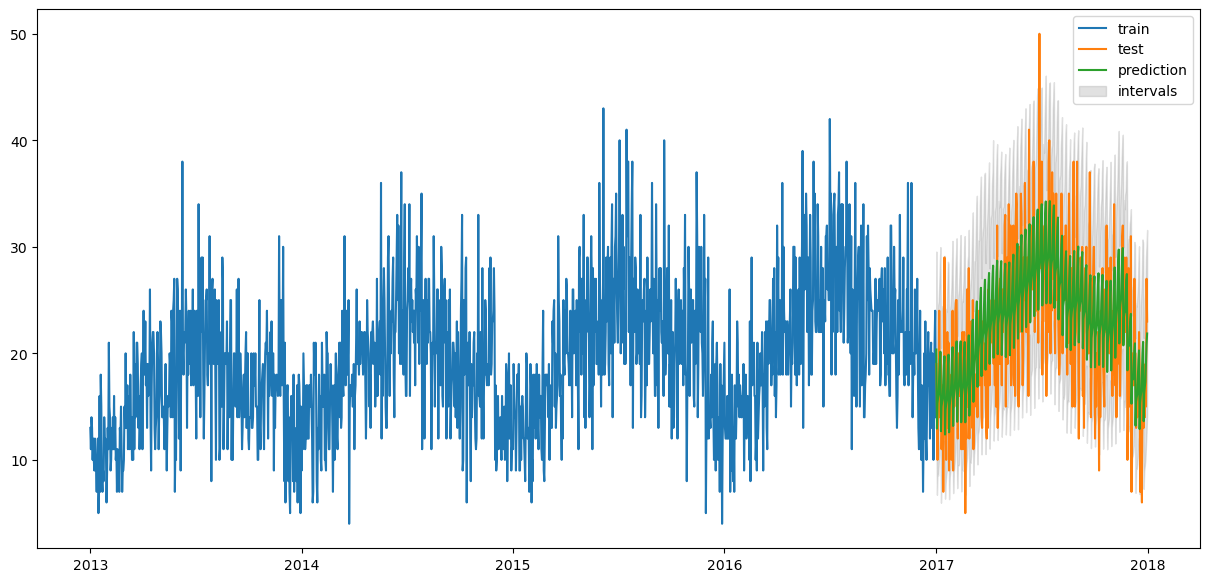

In [31]:
# Визуализация
plot_results(
    data_train, data_test, y_prophet_boxcox_inv,
    plot_conf_int=True,
    left_bound=y_prophet_boxcox_inv_lower, right_bound=y_prophet_boxcox_inv_upper
)

In [32]:
# Метрики
compare_table = add_method_comparison(
    'Prophet + BoxCox', 
    data_test, 
    y_prophet_boxcox_inv, 
    time_fit,
    compare_table
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32


### 4.4. Prophet. Бокс-Кокс + Тонкая настройка (подбор параметров)

In [33]:
# Улучшенная настройка Prophet с Grid Search

# Функция для поиска лучших параметров
def optimize_prophet_params(data_train, data_test, params):
    best_score = float('inf')
    best_params = None
    
    # Преобразование Бокса-Кокса
    data_train_boxcox, lam = stats.boxcox(data_train + 1)
    n_cnt = get_grid_count(params)
    
    for i, param_set in enumerate(ParameterGrid(params)):
        # try:
            # print(param_set)
            time_start = time.time()
            
            # Создаем модель с текущими параметрами
            model = Prophet(
                interval_width=0.95,
                **param_set,
                # yearly_seasonality='auto',
                # weekly_seasonality='auto',
                # daily_seasonality=False
            )
            if 'holidays_prior_scale' in param_set.keys() and param_set['holidays_prior_scale'] > 0:
                model.add_country_holidays(country_name='US')
            
            # Подготовка данных
            df = pd.DataFrame({'ds': data_train.index, 'y': data_train_boxcox})
            
            # Обучение
            model.fit(df)
            time_fit =  time.time() - time_start
            
            # Прогноз
            future   = model.make_future_dataframe(periods=len(data_test))
            forecast = model.predict(future)
            
            # Обратное преобразование
            forecast_boxcox = forecast['yhat'][-len(data_test):].values
            forecast_inv    = invboxcox(forecast_boxcox, lam) - 1
            
            # Оценка
            mape = mean_absolute_percentage_error(data_test, forecast_inv)
            is_best = 0
            if mape < best_score:
                best_score = mape
                best_params = param_set
                is_best = 1

            is_best_text = ' (+)' if is_best else ' '*4
            print(f'{i+1:3} из {n_cnt};{is_best_text} MAPE = {mape:.8f};  MAPE best = {best_score:.8f};' +
                f'  {param_set}')
                
        # except Exception as e:
        #     continue
    
    return best_params, best_score

#### Подбор параметров - часть 1

In [34]:
%%time
# Параметры для перебора
param_grid_prophet_1 = {
    'growth':               ['linear', 'flat'],
    'holidays_prior_scale': [0.0, 0.01, 1.0, 10.0],
    'seasonality_mode':     ['additive', 'multiplicative'],
    'yearly_seasonality':   ['auto'],
    'weekly_seasonality':   ['auto'],
}

print("Оптимизация параметров Prophet...")
best_params, best_score = optimize_prophet_params(data_train, data_test, param_grid_prophet_1)

print("Оптимизация завершена")
print('-' * 100)
print("Лучшее значение MAPE и параметры:")
print('\t', best_score)
print('\t', best_params)

Оптимизация параметров Prophet...
  1 из 16; (+) MAPE = 21.67174644;  MAPE best = 21.67174644;  {'growth': 'linear', 'holidays_prior_scale': 0.0, 'seasonality_mode': 'additive', 'weekly_seasonality': 'auto', 'yearly_seasonality': 'auto'}
  2 из 16; (+) MAPE = 21.23767129;  MAPE best = 21.23767129;  {'growth': 'linear', 'holidays_prior_scale': 0.0, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': 'auto', 'yearly_seasonality': 'auto'}
  3 из 16;     MAPE = 21.58822397;  MAPE best = 21.23767129;  {'growth': 'linear', 'holidays_prior_scale': 0.01, 'seasonality_mode': 'additive', 'weekly_seasonality': 'auto', 'yearly_seasonality': 'auto'}
  4 из 16; (+) MAPE = 21.03567613;  MAPE best = 21.03567613;  {'growth': 'linear', 'holidays_prior_scale': 0.01, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': 'auto', 'yearly_seasonality': 'auto'}
  5 из 16;     MAPE = 21.69264589;  MAPE best = 21.03567613;  {'growth': 'linear', 'holidays_prior_scale': 1.0, 'seasonality_mode': 'add

#### Подбор параметров - часть 2 (Финальное уточнение)

In [35]:
# Финальное уточнение подобранных параметров
param_grid_prophet_2 = {
    'changepoint_prior_scale': [0.0005, 0.001, 0.005],    # Управление гибкостью тренда (ключевой параметр для 'flat')
    'seasonality_prior_scale': [10.0, 20.0, 50.0],        # Сила сезонных компонентов
    'changepoint_range':       [0.8, 0.9, 0.95],          # Доля данных, на которой тренд может меняться,

    # фиксируем парамтры из первого подбора
    'growth':               ['flat'],                  # Фиксируем лучшее значение
    'seasonality_mode':     ['additive'],              # Фиксируем лучшее значение
    'yearly_seasonality':   ['auto'],
    'weekly_seasonality':   ['auto'],
    # 'holidays_prior_scale': [0]
    'holidays':             [None]
}
print("Начинаем оптимизацию Prophet...")
best_params, best_score = optimize_prophet_params(data_train, data_test, param_grid_prophet_2)

print("Оптимизация завершена")
print('-' * 100)
print("Best MAPE и параметры:")
print('\t', best_score)
print('\t', best_params)

Начинаем оптимизацию Prophet...
  1 из 27; (+) MAPE = 19.94242193;  MAPE best = 19.94242193;  {'changepoint_prior_scale': 0.0005, 'changepoint_range': 0.8, 'growth': 'flat', 'holidays': None, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 10.0, 'weekly_seasonality': 'auto', 'yearly_seasonality': 'auto'}
  2 из 27; (+) MAPE = 19.94242185;  MAPE best = 19.94242185;  {'changepoint_prior_scale': 0.0005, 'changepoint_range': 0.8, 'growth': 'flat', 'holidays': None, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 20.0, 'weekly_seasonality': 'auto', 'yearly_seasonality': 'auto'}
  3 из 27; (+) MAPE = 19.94242180;  MAPE best = 19.94242180;  {'changepoint_prior_scale': 0.0005, 'changepoint_range': 0.8, 'growth': 'flat', 'holidays': None, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 50.0, 'weekly_seasonality': 'auto', 'yearly_seasonality': 'auto'}
  4 из 27;     MAPE = 19.94242193;  MAPE best = 19.94242180;  {'changepoint_prior_scale': 0.0005, 'changepoint_ra

### 4.5. Prophet. Лучшая модель

In [36]:
# Обучение модели
prophet_model_combined = Prophet(
    interval_width=0.95,
    **best_params
)
if ('holidays' in best_params) and (not best_params['holidays'] is None):
    prophet_model_combined.add_country_holidays(country_name='US')

time_start = time.time()
prophet_model_combined.fit(prophet_train_boxcox_df)
time_fit = time.time() - time_start

# Прогноз
y_prophet_combined_forecast = prophet_model_combined.predict(future)
y_prophet_combined_forecast.head(3)

# Применяем обратное преобразование
y_prophet_combined_inv       = invboxcox( y_prophet_combined_forecast['yhat'], lam) - 1
y_prophet_combined_inv_lower = invboxcox( y_prophet_combined_forecast['yhat_lower'], lam) - 1
y_prophet_combined_inv_upper = invboxcox( y_prophet_combined_forecast['yhat_upper'], lam) - 1

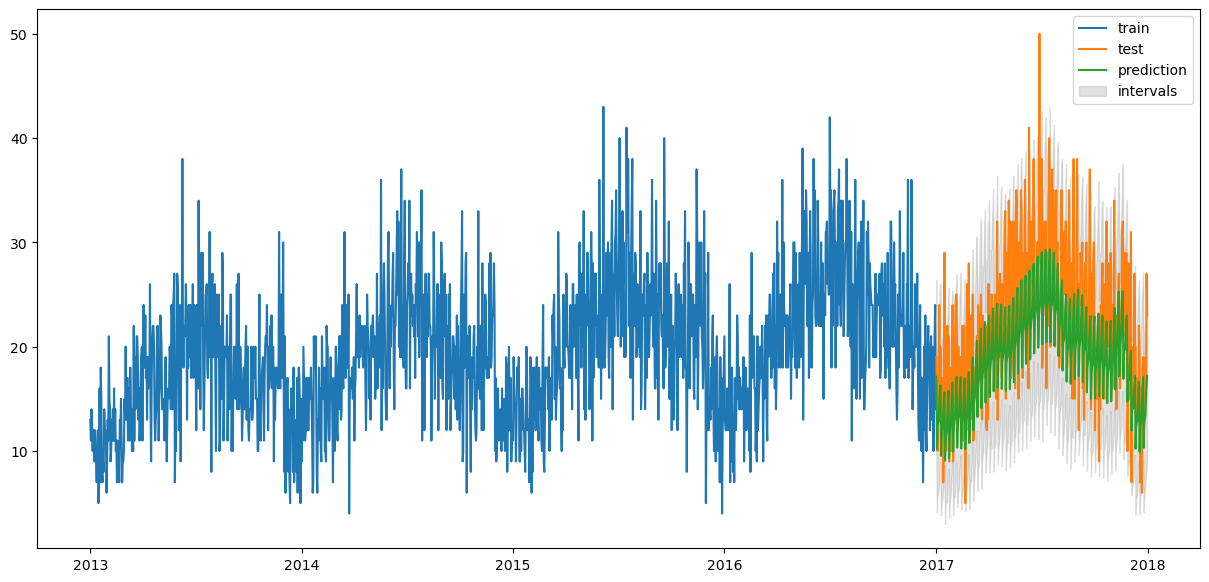

In [37]:
# Визуализация
plot_results(
    data_train, data_test, y_prophet_combined_inv,
    plot_conf_int=True,
    left_bound=y_prophet_combined_inv_lower, right_bound=y_prophet_combined_inv_upper
)

In [38]:
# Метрики
compare_table = add_method_comparison(
    'Prophet Tuned', 
    data_test, 
    y_prophet_combined_inv, 
    time_fit,
    compare_table
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32
3,Prophet Tuned,32.255030,4.433706,19.942422,0.12


### Prophet. Сравнение всех вариантов 

In [39]:
# Выведем сравнение всех вариантов Prophet
prophet_models_comparison = compare_table[compare_table['method'].str.contains('Prophet')]
prophet_models_comparison = prophet_models_comparison.sort_values('MAPE')

print("\nСравнение вариантов Prophet:")
prophet_models_comparison


Сравнение вариантов Prophet:


,method,MSE,MAE,MAPE,time_fit
3,Prophet Tuned,32.255030,4.433706,19.942422,0.12
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32


## 5. AutoARIMA [without exog]

### 5.1. AutoARIMA [without exog]

In [40]:
%%time
time_start = time.time()

arima_model = auto_arima(
    data_train, 
    seasonal=True, 
    m=7,
    
    trace=True,
    error_action='ignore',
    suppress_warnings=True,

    # maxiter=1000,
    # stepwise=False,        # Полный перебор
    # n_jobs=-1,
)
time_fit = time.time() - time_start

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=2.85 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=9794.141, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=9371.474, Time=0.53 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=8926.917, Time=0.40 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=9792.141, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=9013.031, Time=0.06 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=1.65 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=8878.045, Time=1.50 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=5.76 sec
 ARIMA(0,1,0)(0,0,2)[7] intercept   : AIC=9681.707, Time=0.92 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=8872.699, Time=1.96 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=8921.416, Time=0.46 sec
 ARIMA(1,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=6.63 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=1.75 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=9361.603, Time=0

In [41]:
print(f'arima_model.order          = {arima_model.order}')
print(f'arima_model.seasonal_order = {arima_model.seasonal_order}')
print(f'seasonal_periods           = {arima_model.seasonal_order[3]}')

arima_model.order          = (3, 1, 5)
arima_model.seasonal_order = (0, 0, 2, 7)
seasonal_periods           = 7


In [42]:
# Прогноз
y_arima_forecast, conf_int = arima_model.predict(n_periods=test_size, return_conf_int=True, alpha=0.05)

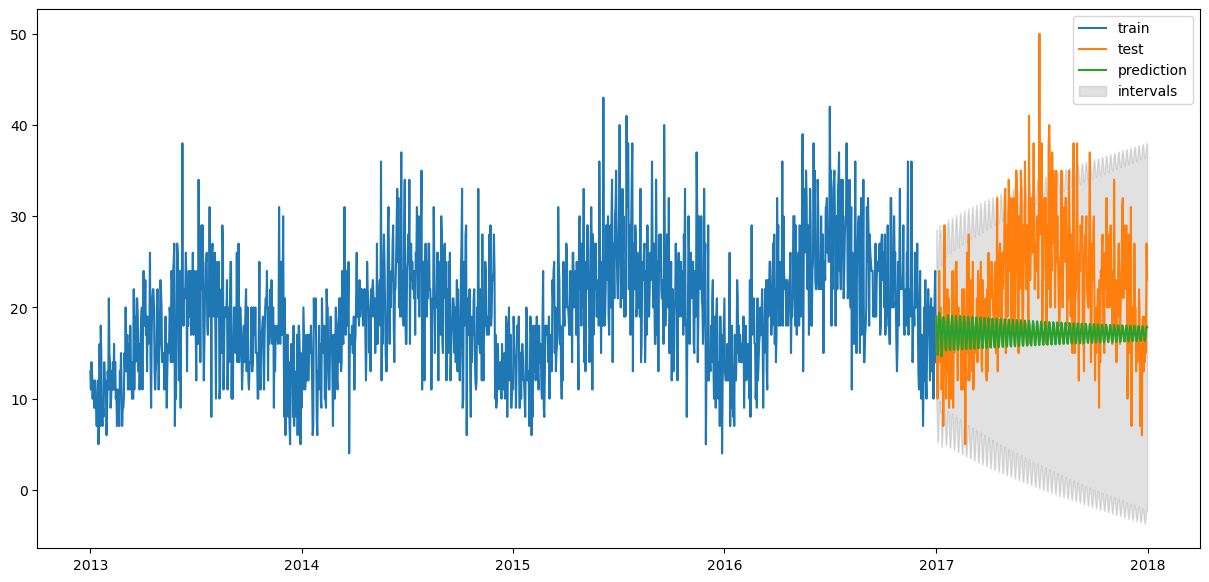

In [43]:
# Визуализация
plot_results(
    data_train, data_test, y_arima_forecast, 
    plot_conf_int=True,
    left_bound=conf_int.T[0], right_bound=conf_int.T[1]
)

In [44]:
compare_table = add_method_comparison(
    'Auto arima model', 
    data_test, 
    y_arima_forecast, 
    time_fit=time_fit,
    compare_table=compare_table
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32
3,Prophet Tuned,32.255030,4.433706,19.942422,0.12
4,Auto arima model,70.529323,6.632215,28.845954,372.34


In [45]:
# arima_model.summary()

In [46]:
# print(arima_model)
# arima_model.get_params()

### 5.2. AutoARIMA exog

In [47]:
exog = pd.DataFrame({'date': data.index})
exog = exog.set_index(exog['date'])

exog['sin365'] = np.sin(2 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365'] = np.cos(2 * np.pi * exog.index.dayofyear / 365.25)

exog['sin365_2'] = np.sin(4 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365_2'] = np.cos(4 * np.pi * exog.index.dayofyear / 365.25)

exog = exog.drop(columns=['date'])

exog_to_train = exog.iloc[:-test_size]
exog_to_test  = exog.iloc[-test_size:]

print("Экзогенные переменные созданы") 
print(f"Размеры:\n\texog_to_train: {exog_to_train.shape}\n\texog_to_test:  {exog_to_test.shape}")

Экзогенные переменные созданы
Размеры:
	exog_to_train: (1461, 4)
	exog_to_test:  (365, 4)


**todo**: 
- Используйте модель `auto_arima` с экзогенными переменными, которые созданы выше (их не надо менять).
- Посчитайте метрики качества и добавьте их в датафрейм (сравнительную таблицу) с метриками по всем обученным до этого моделям.

In [48]:
%%time
# Обучение модели
print('Обучение модели auto_arima c экзогенными параметрами...\n')
time_start = time.time()

arima_model_exog = auto_arima(
    data_train, 
    seasonal=True, 
    m=7,
    
    exogenous=exog_to_train,   # экзогенные переменные
    
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    
    # with_intercept=True,    # Разрешить константу
    # maxiter=1000,
    # stepwise=False,           # Полный перебор
    # n_jobs=-1,                # 
)

time_fit = time.time() - time_start
print()

Обучение модели auto_arima c экзогенными параметрами...

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=2.90 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=9794.141, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=9371.474, Time=0.55 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=8926.917, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=9792.141, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=9013.031, Time=0.06 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=1.35 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=8878.045, Time=1.48 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=5.95 sec
 ARIMA(0,1,0)(0,0,2)[7] intercept   : AIC=9681.707, Time=0.90 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=8872.699, Time=1.94 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=8921.416, Time=0.48 sec
 ARIMA(1,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=6.53 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=1.75 sec
 

In [49]:
print(f'arima_model_exog.order          = {arima_model_exog.order}')
print(f'arima_model_exog.seasonal_order = {arima_model_exog.seasonal_order}')
print(f'seasonal_periods                = {arima_model_exog.seasonal_order[3]}')

arima_model_exog.order          = (3, 1, 5)
arima_model_exog.seasonal_order = (0, 0, 2, 7)
seasonal_periods                = 7


In [50]:
# Прогноз с экзогенными переменными
y_arima_exog_forecast, conf_int_exog = arima_model_exog.predict(
    n_periods=test_size, 
    exogenous=exog_to_test, 
    return_conf_int=True, 
    alpha=0.05
)

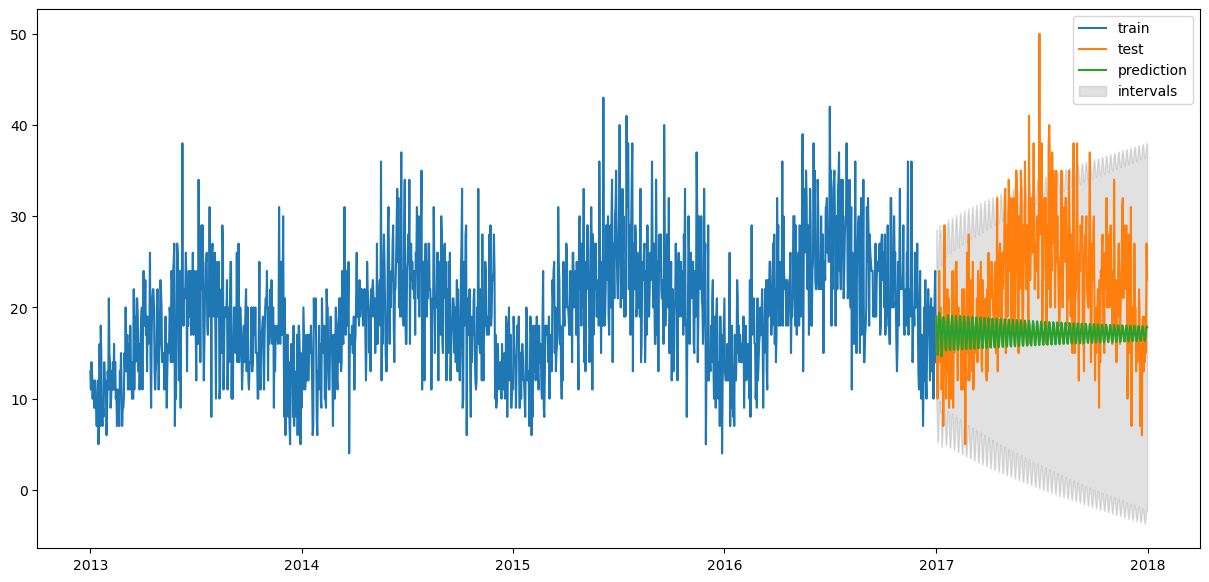

In [51]:
# Визуализация
plot_results(
    data_train, data_test, y_arima_exog_forecast, 
    plot_conf_int=True,
    left_bound=conf_int_exog.T[0], right_bound=conf_int_exog.T[1]
)

In [52]:
compare_table = add_method_comparison(
    'Auto arima model + exog', 
    data_test, 
    y_arima_exog_forecast,
    time_fit=time_fit,
    compare_table=compare_table
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32
3,Prophet Tuned,32.255030,4.433706,19.942422,0.12
4,Auto arima model,70.529323,6.632215,28.845954,372.34
5,Auto arima model + exog,70.529323,6.632215,28.845954,366.78


In [53]:
# print(arima_model_exog)
# arima_model_exog.get_params()

### 5.3. AutoARIMA. Улучшенная модель

#### Дополнительные экзогенные переменные (one-hot encoding)
- День недели
- Месяц
- Квартал
- Признак выходного дня

In [54]:
# Основные экзогенные переменные

exog = pd.DataFrame({'date': data.index})
exog = exog.set_index(exog['date'])

exog['sin365'] = np.sin(2 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365'] = np.cos(2 * np.pi * exog.index.dayofyear / 365.25)

exog['sin365_2'] = np.sin(4 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365_2'] = np.cos(4 * np.pi * exog.index.dayofyear / 365.25)

exog = exog.drop(columns=['date'])

#--------------------------------------------------------------------------------------------------------
# Дополнительные экзогенные переменные (one-hot encoding)
    # День недели
    # Месяц
    # Квартал
    # Признак выходного дня

for i in range(7):
    exog[f'dayofweek_{i}'] = (exog.index.dayofweek == i).astype(int)

for i in range(1, 13):
    exog[f'month_{i}'] = (exog.index.month == i).astype(int)

for i in range(1, 5):
    exog[f'quarter_{i}'] = (exog.index.quarter == i).astype(int)

exog['is_weekend'] = (exog.index.dayofweek >= 5).astype(int)

print(f"Создано {exog.shape[1]} экзогенных переменных")

#--------------------------------------------------------------------------------------------------------
exog_to_train = exog.iloc[:-test_size]
exog_to_test  = exog.iloc[-test_size:]

print("Экзогенные переменные созданы") 
print(f"Размеры:\n\texog_to_train: {exog_to_train.shape}\n\texog_to_test:  {exog_to_test.shape}")

Создано 28 экзогенных переменных
Экзогенные переменные созданы
Размеры:
	exog_to_train: (1461, 28)
	exog_to_test:  (365, 28)


In [94]:
%%time
# Обучение модели
print('Обучение модели auto_arima c расширенными экзогенными параметрами...\n')
time_start = time.time()

arima_improved = auto_arima(
    data_train, 
    seasonal=True, 
    m=7,
    
    exogenous=exog_to_train,   # экзогенные переменные
    
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    
    # with_intercept=True,    # Разрешить константу
    maxiter=1000,
    stepwise=False,           # Полный перебор
    n_jobs=-1,                # 
)

time_fit = time.time() - time_start
print()

Обучение модели auto_arima c расширенными экзогенными параметрами...


Best model:  ARIMA(0,1,2)(2,0,0)[7] intercept
Total fit time: 30.222 seconds

CPU times: total: 6.08 s
Wall time: 30.4 s


In [56]:
# Прогноз
y_arima_improved_forecast, conf_int_improved = arima_improved.predict(
    n_periods=test_size, 
    exogenous=exog_to_test,
    return_conf_int=True, 
    alpha=0.05
)

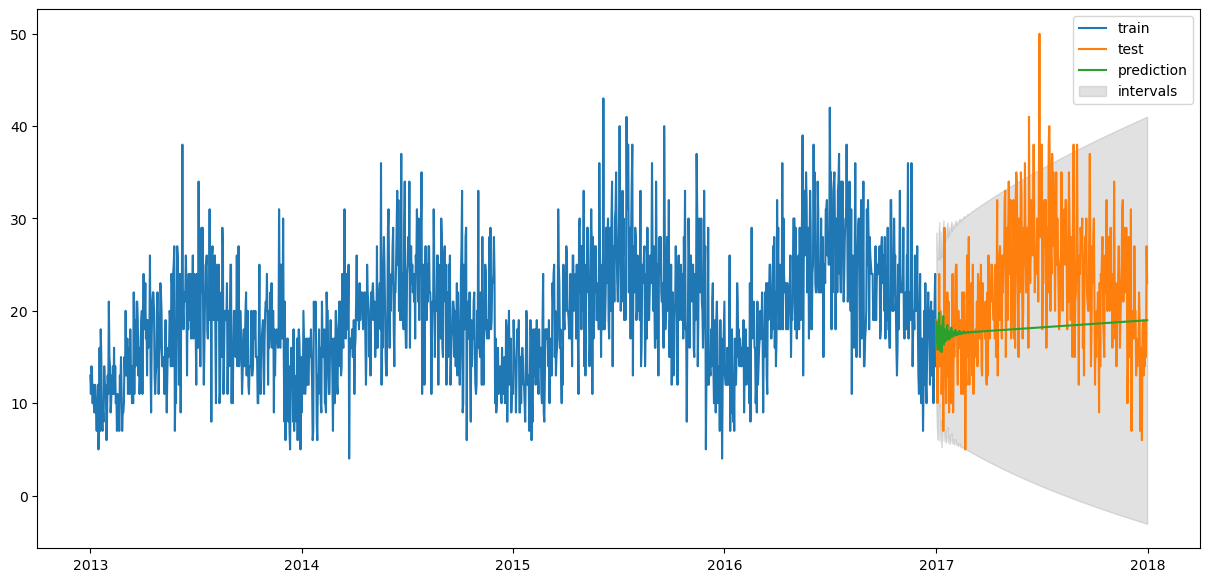

In [57]:
# Визуализация
plot_results(
    data_train, data_test, y_arima_improved_forecast, 
    plot_conf_int=True,
    left_bound=conf_int_improved.T[0], right_bound=conf_int_improved.T[1]
)

In [58]:
compare_table = add_method_comparison(
    'Auto arima improved', 
    data_test, 
    y_arima_improved_forecast, 
    time_fit=time_fit,
    compare_table=compare_table
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32
3,Prophet Tuned,32.255030,4.433706,19.942422,0.12
4,Auto arima model,70.529323,6.632215,28.845954,372.34
5,Auto arima model + exog,70.529323,6.632215,28.845954,366.78
6,Auto arima improved,62.968799,6.212377,28.091842,30.24


### 5.4. AutoARIMA. Сравнение всех вариантов 

In [59]:
# Выведем сравнение всех вариантов Prophet
auto_arima_models_comparison = compare_table[compare_table['method'].str.contains('Auto arima')]
auto_arima_models_comparison = auto_arima_models_comparison.sort_values('MAPE')

print("\nСравнение вариантов auto_arima:")
# print(auto_arima_models_comparison)
auto_arima_models_comparison


Сравнение вариантов auto_arima:


,method,MSE,MAE,MAPE,time_fit
6,Auto arima improved,62.968799,6.212377,28.091842,30.24
4,Auto arima model,70.529323,6.632215,28.845954,372.34
5,Auto arima model + exog,70.529323,6.632215,28.845954,366.78


## 6. SARIMAX [without exog]

### 6.1. SARIMAX [without exog]

In [60]:
print(f'arima_model.order          = {arima_model.order}')
print(f'arima_model.seasonal_order = {arima_model.seasonal_order}')
print(f'seasonal_periods           = {arima_model.seasonal_order[3]}')

arima_model.order          = (3, 1, 5)
arima_model.seasonal_order = (0, 0, 2, 7)
seasonal_periods           = 7


In [61]:
%%time
data_train_series = data_train.asfreq('D')

# Передаем параметры из прошлой модели (arima_model)
sarimax_model = SARIMAX(
    
    data_train_series, 
    # data_train,
    
    order          = (3, 1, 5),         # Значения при stepwise=True
    seasonal_order = (0, 0, 2, 7),      # Значения при stepwise=True
    
    # order          = (0, 1, 2),       # Значения при stepwise=False
    # seasonal_order = (2, 0, 0, 7)     # Значения при stepwise=False
)

CPU times: total: 15.6 ms
Wall time: 5 ms


In [62]:
%%time
# Обучение модели
time_start = time.time()

# Увеличено число итерация для схождения модели
real_sarimax_model = sarimax_model.fit(maxiter=1000)

print(f"\nРезультаты модели:")
print(f"\tАлгоритм сошелся:   {real_sarimax_model.mle_retvals['converged']}")
print(f"\tИтераций:           {real_sarimax_model.mle_retvals['iterations']}")
# print(f"\tЛог-правдоподобие:  {real_sarimax_model.llf:.2f}")
print(f"\tAIC:                {real_sarimax_model.aic:.2f}\n")

time_fit = time.time() - time_start


Результаты модели:
	Алгоритм сошелся:   True
	Итераций:           143
	AIC:                8757.85

CPU times: total: 38.4 s
Wall time: 43 s


In [63]:
# Прогноз
forecast = real_sarimax_model.get_forecast( steps=len(data_test) )

y_sarimax_real_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

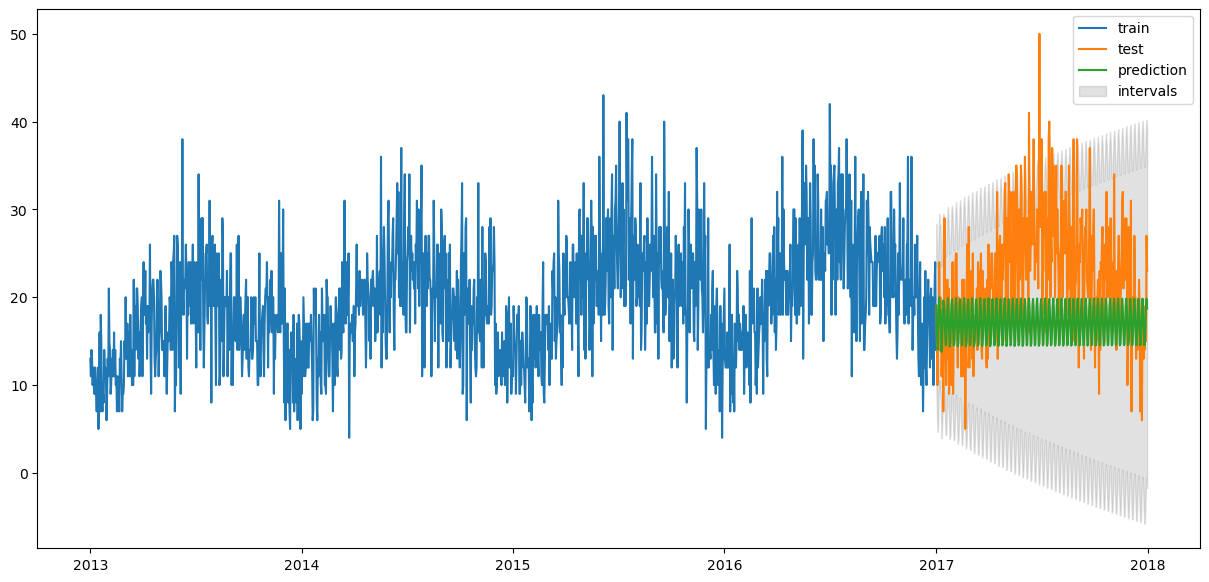

In [64]:
# Визуализация
plot_results(
    data_train, data_test, y_sarimax_real_forecast, 
    plot_conf_int=True,
    left_bound=conf_int['lower sales'], right_bound=conf_int['upper sales']
)

In [65]:
compare_table = add_method_comparison(
    'SARIMAX original', 
    data_test, 
    y_sarimax_real_forecast, 
    time_fit=time_fit,
    compare_table=compare_table
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32
3,Prophet Tuned,32.255030,4.433706,19.942422,0.12
4,Auto arima model,70.529323,6.632215,28.845954,372.34
5,Auto arima model + exog,70.529323,6.632215,28.845954,366.78
6,Auto arima improved,62.968799,6.212377,28.091842,30.24
7,SARIMAX original,68.968723,6.599315,28.755754,42.97


### 6.2. SARIMAX with exog

In [66]:
exog = pd.DataFrame({'date': data.index})
exog = exog.set_index(exog['date'])

exog['sin365'] = np.sin(2 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365'] = np.cos(2 * np.pi * exog.index.dayofyear / 365.25)

exog['sin365_2'] = np.sin(4 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365_2'] = np.cos(4 * np.pi * exog.index.dayofyear / 365.25)

exog = exog.drop(columns=['date'])

exog_to_train = exog.iloc[:-test_size]
exog_to_test  = exog.iloc[-test_size:]

todo: 
- Используйте модель `SARIMAX` с экзогенными переменными, которые созданы выше (их не надо менять), для улучшения предсказаний.

In [67]:
print(f'arima_model_exog.order          = {arima_model_exog.order}')
print(f'arima_model_exog.seasonal_order = {arima_model_exog.seasonal_order}')
print(f'seasonal_periods                = {arima_model_exog.seasonal_order[3]}')

arima_model_exog.order          = (3, 1, 5)
arima_model_exog.seasonal_order = (0, 0, 2, 7)
seasonal_periods                = 7


In [68]:
%%time
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
warnings.filterwarnings("ignore", message="No frequency information was provided")

print("Обучение модели SARIMAX с экзогенными переменными...")

data_train_series = data_train.asfreq('D')

time_start = time.time()

# Используем параметры из модели arima_model_exog
sarimax_model_exog = SARIMAX(
    
    data_train_series,
    # data_train,

    exog=exog_to_train,                 # Добавляем экзогенные переменные
    
    order          = (3, 1, 5),         # значения из модели arima_model_exog при stepwise=True
    seasonal_order = (0, 0, 2, 7),      # значения из модели arima_model_exog при stepwise=True
    
    # order          = (0, 1, 2),         # значения из модели arima_model_exog при stepwise=False
    # seasonal_order = ( 2, 0, 0, 7),     # значения из модели arima_model_exog при stepwise=False
    
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Обучаем модель
real_sarimax_model_exog = sarimax_model_exog.fit(maxiter=1000)

print(f"\nРезультаты модели:")
print(f"\tАлгоритм сошелся:   {real_sarimax_model_exog.mle_retvals['converged']}")
print(f"\tИтераций:           {real_sarimax_model_exog.mle_retvals['iterations']}")
# print(f"\tЛог-правдоподобие:  {real_sarimax_model_exog.llf:.2f}")
print(f"\tAIC:                {real_sarimax_model_exog.aic:.2f}\n")

time_fit = time.time() - time_start 

Обучение модели SARIMAX с экзогенными переменными...

Результаты модели:
	Алгоритм сошелся:   True
	Итераций:           166
	AIC:                8621.86

CPU times: total: 1min 29s
Wall time: 1min 33s


In [69]:
# Прогноз с экзогенными переменными
forecast_exog = real_sarimax_model_exog.get_forecast(
    steps=len(data_test),
    exog=exog_to_test      # Экзогенные переменные для прогноза
)

y_sarimax_exog_forecast = forecast_exog.predicted_mean
conf_int_exog = forecast_exog.conf_int()

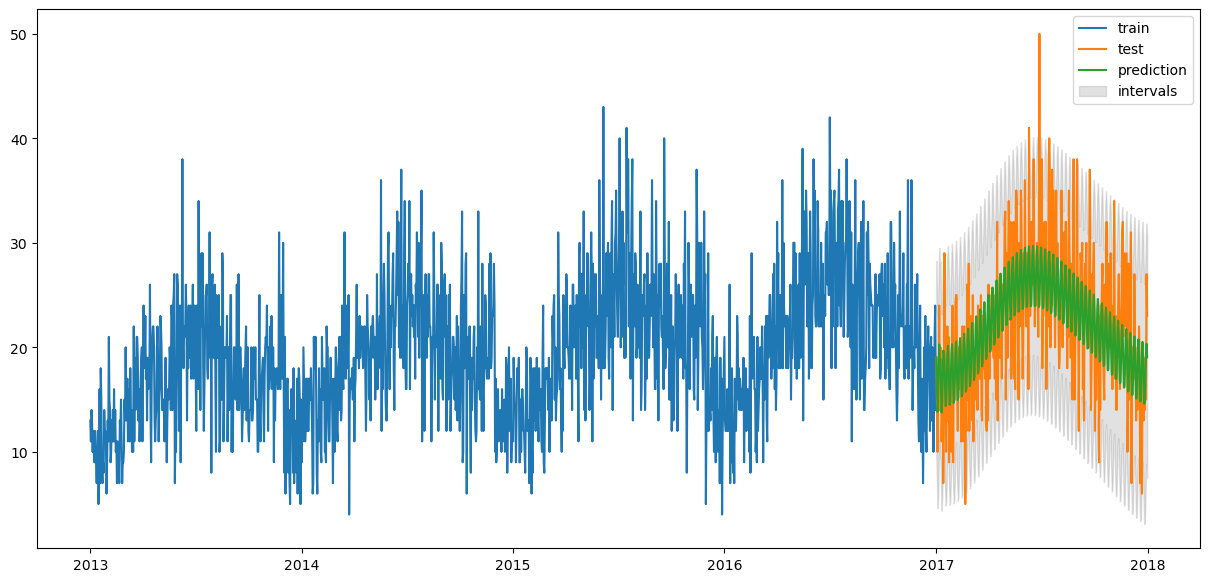

In [70]:
# Визуализация и метрики
plot_results(
    data_train, data_test, y_sarimax_exog_forecast,
     plot_conf_int=True,
     left_bound=conf_int_exog['lower sales'],
     right_bound=conf_int_exog['upper sales']
)

In [71]:
# Добавляем в таблицу сравнения
compare_table = add_method_comparison(
    'SARIMAX + exog', 
    data_test, 
    y_sarimax_exog_forecast,
    time_fit=time_fit,
    compare_table=compare_table
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32
3,Prophet Tuned,32.255030,4.433706,19.942422,0.12
4,Auto arima model,70.529323,6.632215,28.845954,372.34
5,Auto arima model + exog,70.529323,6.632215,28.845954,366.78
6,Auto arima improved,62.968799,6.212377,28.091842,30.24
7,SARIMAX original,68.968723,6.599315,28.755754,42.97
8,SARIMAX + exog,28.371378,4.219990,22.401961,93.41


### 6.3. SARIMAX. Лучшая модель. Подбор параметров

#### Дополнительные экзогенные переменные (one-hot encoding):
- День недели
- Месяц
- Квартал
- Признак выходного дня

In [72]:
# Основные экзогенные переменные

exog = pd.DataFrame({'date': data.index})
exog = exog.set_index(exog['date'])

exog['sin365'] = np.sin(2 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365'] = np.cos(2 * np.pi * exog.index.dayofyear / 365.25)

exog['sin365_2'] = np.sin(4 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365_2'] = np.cos(4 * np.pi * exog.index.dayofyear / 365.25)

exog = exog.drop(columns=['date'])

#--------------------------------------------------------------------------------------------------------
# Дополнительные экзогенные переменные (one-hot encoding)
    # День недели
    # Месяц
    # Квартал
    # Признак выходного дня

for i in range(7):
    exog[f'dayofweek_{i}'] = (exog.index.dayofweek == i).astype(int)

for i in range(1, 13):
    exog[f'month_{i}'] = (exog.index.month == i).astype(int)

for i in range(1, 5):
    exog[f'quarter_{i}'] = (exog.index.quarter == i).astype(int)

exog['is_weekend'] = (exog.index.dayofweek >= 5).astype(int)

print(f"Создано {exog.shape[1]} экзогенных переменных")

#--------------------------------------------------------------------------------------------------------
exog_to_train = exog.iloc[:-test_size]
exog_to_test  = exog.iloc[-test_size:]

print("Экзогенные переменные созданы") 
print(f"Размеры:\n\texog_to_train: {exog_to_train.shape}\n\texog_to_test:  {exog_to_test.shape}")

Создано 28 экзогенных переменных
Экзогенные переменные созданы
Размеры:
	exog_to_train: (1461, 28)
	exog_to_test:  (365, 28)


In [73]:
#--- Широкие диапазоны ---
# Основные параметры ARIMA (p,d,q)
# p_range = [1, 2, 3]      # Авторегрессия: 1-3 (включительно 2)
# d_range = [1]            # Дифференцирование: фиксируем 1 (ряд нестационарен)
# q_range = [1, 2, 3]      # Скользящее среднее: 1-3 (включительно 2)

# # Сезонные параметры (P,D,Q,s)
# P_range = [0, 1]         # Сезонная авторегрессия: 0 или 1
# D_range = [0]            # Сезонное дифф.: 0 (сезонность уже в exog)
# Q_range = [1, 2]         # Сезонное скользящее среднее: 1 или 2
# s = 7                    # Период сезонности фиксирован

#--- Узкие диапазоны ---
p_range = [2, 3]         # AR: 2-3
d_range = [1]            # Дифференцирование: фиксируем 1 (ряд нестационарен)
q_range = [2, 3]         # MA: 2-3    [2, 3, 4, 5]

P_range = [0, 1]         # Сезонный AR: 0 или 1
D_range = [0]            # Сезонное дифф.: 0 (сезонность уже в exog)
Q_range = [1]            # Сезонный MA: 1 (Q=2 даёт схожие результаты, но дольше)
s = 7                    # Период сезонности фиксирован

In [74]:
%%time
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
warnings.filterwarnings("ignore", message="No frequency information was provided")

best_mape = float('inf')
best_params = {}
best_model = None

# Счётчик для прогресса
total_combinations = len(p_range) * len(d_range) * len(q_range) * len(P_range) * len(D_range) * len(Q_range)
current = 0

print(f"Всего комбинаций для перебора: {total_combinations}")
print("-" * 150)

# Основной цикл перебора
for p, d, q, P, D, Q in itertools.product(p_range, d_range, q_range, P_range, D_range, Q_range):
    
    current += 1
    print(f"Комбинация {current:2} из {total_combinations:2}: SARIMAX ({p},{d},{q})({P},{D},{Q},{s});", end=" ")
    time_start = time.time()
    is_best = 0
    
    try:
        # Создаём и обучаем модель
        model = SARIMAX(
            
            data_train_series,
            exog=exog_to_train,
            
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            
            enforce_stationarity=False,
            enforce_invertibility=False,
            # trend='n'                   # Без константы, так как в exog уже есть сезонность
        )
        
        results = model.fit(
            maxiter=1000,
            # method='lbfgs',
            # disp=False,
            # cov_type='none'
        )
        
        # Прогноз и оценка
        forecast = results.get_forecast( steps=len(data_test), exog=exog_to_test )
        mape     = mean_absolute_percentage_error(data_test, forecast.predicted_mean)
        time_fit = time.time() - time_start
        params   = {'order': (p, d, q), 'seasonal_order': (P, D, Q, s)}
        
        # Сохраняем лучшую модель
        if mape < best_mape:
            best_mape     = mape
            best_params   = params
            best_model    = results
            best_time_fit = time_fit
            is_best       = 1
            
        is_best_text = ' (+)' if is_best else ' '*4
        print(f'{is_best_text} MAPE = {mape:.8f};  MAPE best = {best_mape:.8f};  time_fit = {time_fit:.1f}')
            
    except Exception as e:
        print(f"- Ошибка: {str(e)[:50]}...")
        continue
        
    # if current == 1:
    #     break
        
print("-" * 150)
print(f"Лучшая модель:")
print(f"  MAPE:      {best_mape:.8f}")
print(f"  AIC:       {best_model.aic:.2f}")
print(f"  Параметры: order={best_params['order']}, seasonal_order={best_params['seasonal_order']}\n")


Всего комбинаций для перебора: 8
------------------------------------------------------------------------------------------------------------------------------------------------------
Комбинация  1 из  8: SARIMA (2,1,2)(0,0,1,7);  (+) MAPE = 19.93283189;  MAPE best = 19.93283189;  time_fit = 69.6
Комбинация  2 из  8: SARIMA (2,1,2)(1,0,1,7);  (+) MAPE = 19.88603856;  MAPE best = 19.88603856;  time_fit = 78.3
Комбинация  3 из  8: SARIMA (2,1,3)(0,0,1,7);      MAPE = 19.93050766;  MAPE best = 19.88603856;  time_fit = 77.6
Комбинация  4 из  8: SARIMA (2,1,3)(1,0,1,7);  (+) MAPE = 19.88265599;  MAPE best = 19.88265599;  time_fit = 39.7
Комбинация  5 из  8: SARIMA (3,1,2)(0,0,1,7);      MAPE = 19.92885109;  MAPE best = 19.88265599;  time_fit = 48.7
Комбинация  6 из  8: SARIMA (3,1,2)(1,0,1,7);      MAPE = 19.93282299;  MAPE best = 19.88265599;  time_fit = 66.6
Комбинация  7 из  8: SARIMA (3,1,3)(0,0,1,7);      MAPE = 19.92837886;  MAPE best = 19.88265599;  time_fit = 82.3
Комбинация  8 из  

In [75]:
# Прогноз
forecast_improved = best_model.get_forecast(
    steps=len(data_test),
    exog=exog_to_test
)

y_sarimax_improved_forecast = forecast_improved.predicted_mean
conf_int_improved = forecast_improved.conf_int()

In [76]:
# Прогноз лучшей модели
sarimax_forecast_best_model  = best_model.get_forecast(
    steps=len(data_test),
    exog=exog_to_test
)

y_sarimax_forecast_best_model = sarimax_forecast_best_model.predicted_mean
conf_int_sarimax_best_model = sarimax_forecast_best_model.conf_int()

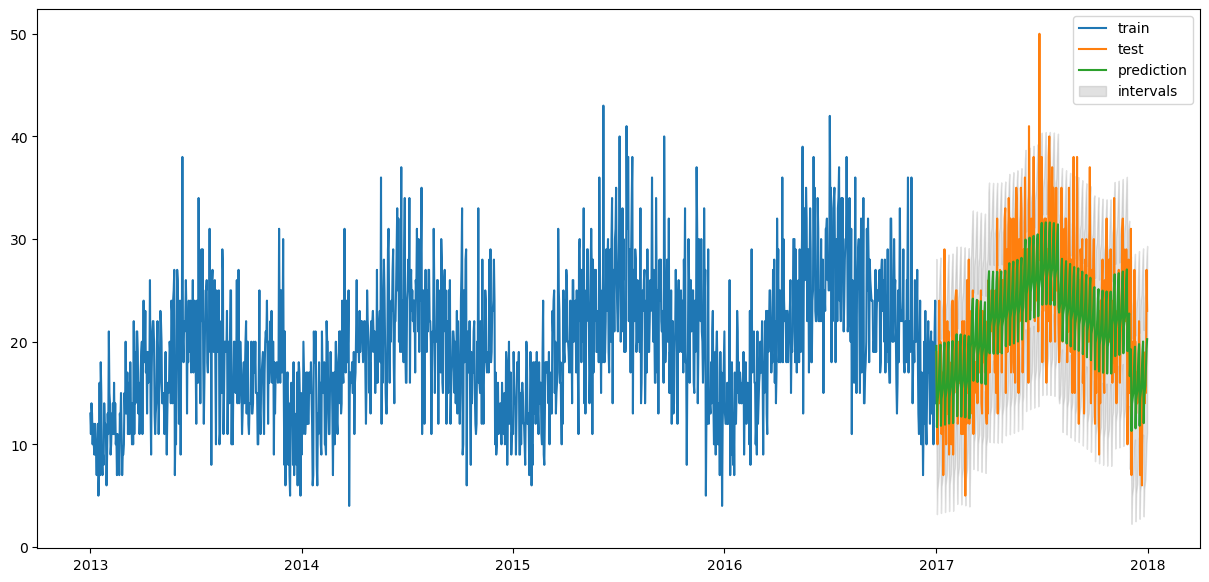

In [77]:
# Визуализация и метрики
plot_results(
    data_train, data_test, y_sarimax_forecast_best_model,
    plot_conf_int=True,
    left_bound=conf_int_sarimax_best_model['lower sales'],
    right_bound=conf_int_sarimax_best_model['upper sales']
)

In [78]:
# Сохранение лучшей модели SARIMAX в таблицу сравнения
compare_table = add_method_comparison(
    'SARIMAX Tuned',
    data_test,
    y_sarimax_forecast_best_model,
    time_fit=best_time_fit,
    compare_table=compare_table
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32
3,Prophet Tuned,32.255030,4.433706,19.942422,0.12
4,Auto arima model,70.529323,6.632215,28.845954,372.34
5,Auto arima model + exog,70.529323,6.632215,28.845954,366.78
6,Auto arima improved,62.968799,6.212377,28.091842,30.24
7,SARIMAX original,68.968723,6.599315,28.755754,42.97
8,SARIMAX + exog,28.371378,4.219990,22.401961,93.41
9,SARIMAX Tuned,23.408602,3.870457,19.882656,39.68


### 6.4. SARIMAX. Сравнение всех вариантов 

In [79]:
# Выведем сравнение всех вариантов Prophet
sarimax_models_comparison = compare_table[compare_table['method'].str.contains('SARIMAX')]
sarimax_models_comparison = sarimax_models_comparison.sort_values('MAPE')

print("\nСравнение вариантов SARIMAX:")
sarimax_models_comparison


Сравнение вариантов SARIMAX:


,method,MSE,MAE,MAPE,time_fit
9,SARIMAX Tuned,23.408602,3.870457,19.882656,39.68
8,SARIMAX + exog,28.371378,4.219990,22.401961,93.41
7,SARIMAX original,68.968723,6.599315,28.755754,42.97


## 7. TBATS

Модель учитывает несколько сезонностей, но не может принимать экзогенные признаки.

In [80]:
%%time
# Обучение модели
tbats_estimator = TBATS(seasonal_periods=(7, 180))
model = tbats_estimator.fit(data_train)

CPU times: total: 8.42 s
Wall time: 2min 20s


In [81]:
print(model.summary())

Use Box-Cox: False
Use trend: False
Use damped trend: False
Seasonal periods: [  7. 180.]
Seasonal harmonics [3 3]
ARMA errors (p, q): (0, 0)
Smoothing (Alpha): 0.099254
Seasonal Parameters (Gamma): [ 0.00073055  0.00126939 -0.00168362 -0.0007157 ]
AR coefficients []
MA coefficients []
Seed vector [11.64783078 -2.63361686 -0.19728629  1.19371923 -0.73577877  1.77368199
  0.93247816  0.28014787 -0.22456824 -0.7175311  -0.93148604 -0.02311377
  0.1540708 ]

AIC 15098.062904


In [82]:
# Прогноз
tbats_forecast, confidence_info = model.forecast(steps=365, confidence_level=0.95)

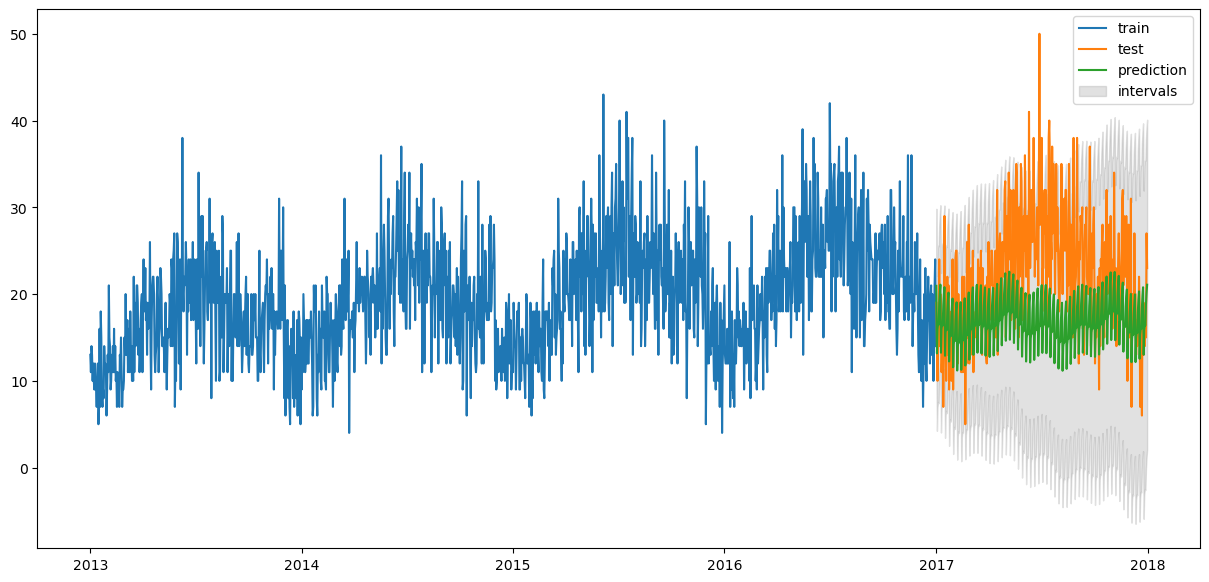

In [83]:
# Визуализация
plot_results(data_train, data_test, tbats_forecast, plot_conf_int=True,
             left_bound=confidence_info['lower_bound'],
             right_bound=confidence_info['upper_bound'])

In [84]:
compare_table = add_method_comparison(
    'TBATS model', 
    data_test, 
    tbats_forecast, 
    time_fit=time_fit,
    compare_table=compare_table
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32
3,Prophet Tuned,32.255030,4.433706,19.942422,0.12
4,Auto arima model,70.529323,6.632215,28.845954,372.34
5,Auto arima model + exog,70.529323,6.632215,28.845954,366.78
6,Auto arima improved,62.968799,6.212377,28.091842,30.24
7,SARIMAX original,68.968723,6.599315,28.755754,42.97
8,SARIMAX + exog,28.371378,4.219990,22.401961,93.41
9,SARIMAX Tuned,23.408602,3.870457,19.882656,39.68


### 7.1. TBATS. Подбор параметров - часть 1

In [85]:
%%time
# 7.1. TBATS - подбор параметров - часть 1

tbats_params = [
    {'use_box_cox': True,  'use_trend': False, 'use_damped_trend': False},
    {'use_box_cox': True,  'use_trend': True,  'use_damped_trend': False},
    {'use_box_cox': True,  'use_trend': True,  'use_damped_trend': True},
    {'use_box_cox': False, 'use_trend': True,  'use_damped_trend': True},
]

best_tbats_model = None
best_tbats_mape = float('inf')
n_cnt = len(tbats_params)

for i, params in enumerate(tbats_params):
    # try:
        time_start = time.time()
        
        estimator = TBATS(
            seasonal_periods=(7, 30, 365),  # сезонность
            **params
        )
        
        model = estimator.fit(data_train)
        time_fit = time.time() - time_start
        
        forecast_tbats = model.forecast(steps=test_size)
        
        mape = mean_absolute_percentage_error(data_test, forecast_tbats)
        is_best = 0
        if mape < best_tbats_mape:
            best_tbats_mape   = mape
            best_tbats_model  = model
            best_tbats_params = params
            best_time_fit     = time_fit
            is_best = 1
        
        is_best_text = ' (+)' if is_best else ' '*4

        # Добавление сезонности (для вывода лога)
        all_params = params.copy()
        all_params['seasonal_periods'] = (7, 30, 365)

        print(f'{i+1:3} из {n_cnt};{is_best_text} MAPE = {mape:.8f};  MAPE best = {best_tbats_mape:.8f};  time_fit = {time_fit:.1f};  params = {all_params}')
        
    # except Exception as e:
    #     continue

print('-' * 100)
print(f"Лучший MAPE:            {best_tbats_mape:.4f}")
print(f"Лучшие параметры TBATS: {best_tbats_params}")

  1 из 4; (+) MAPE = 20.94034873;  MAPE best = 20.94034873;  time_fit = 215.7;  params = {'use_box_cox': True, 'use_trend': False, 'use_damped_trend': False, 'seasonal_periods': (7, 30, 365)}
  2 из 4;     MAPE = 320.34007288;  MAPE best = 20.94034873;  time_fit = 209.6;  params = {'use_box_cox': True, 'use_trend': True, 'use_damped_trend': False, 'seasonal_periods': (7, 30, 365)}
  3 из 4; (+) MAPE = 20.16982947;  MAPE best = 20.16982947;  time_fit = 192.8;  params = {'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'seasonal_periods': (7, 30, 365)}
  4 из 4;     MAPE = 20.43549932;  MAPE best = 20.16982947;  time_fit = 142.8;  params = {'use_box_cox': False, 'use_trend': True, 'use_damped_trend': True, 'seasonal_periods': (7, 30, 365)}
----------------------------------------------------------------------------------------------------
Лучший MAPE:            20.1698
Лучшие параметры TBATS: {'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True}
CPU times: 

### 7.2. TBATS. Подбор параметров - часть 2

In [86]:
%%time
# 7.2. TBATS - подбор параметров - часть 2

# Основа: лучшая найденная конфигурация в части 1 + 
    # Моделирование ошибок (use_arma_errors = True) +
    # Добавление различной сезонности + 
    # Границы Box-Cox (для стабильности)

# Перебор кортежей (параметры + сезонность)
tbats_configs = [
    # Основная комбинация из части 1
    ({'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'use_arma_errors': True}, (7, 30, 365)),
    
    # Моделирование ошибок (use_arma_errors = True) + Сезонность не задана
    ({'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'use_arma_errors': True}, None),
    
    # Различные комбинации сезонностей с use_arma_errors = True
    ({'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'use_arma_errors': True}, [7]),
    ({'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'use_arma_errors': True}, [365.25]),
    ({'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'use_arma_errors': True}, [7, 365.25]),
    
    # Сезонность [7, 365.25] с ограниченным Box-Cox
    ({'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'use_arma_errors': True, 'box_cox_bounds': (0, 1)}, [7, 365.25]),
]

best_tbats_model    = None
best_tbats_mape     = float('inf')
best_tbats_params   = None
best_tbats_seasonal = None
best_time_fit       = 0 

n_cnt = len(tbats_configs)

for i, (params, seasonal_periods) in enumerate(tbats_configs):
    try:
        time_start = time.time()

        estimator = TBATS(
            seasonal_periods=seasonal_periods,
            **params
        )
        
        model = estimator.fit(data_train)
        time_fit = time.time() - time_start
        
        forecast_tbats = model.forecast(steps=test_size)
        
        mape = mean_absolute_percentage_error(data_test, forecast_tbats)
        is_best = 0
        if mape < best_tbats_mape:
            best_tbats_mape = mape
            best_tbats_model = model
            best_tbats_params = params
            best_tbats_seasonal = seasonal_periods
            best_time_fit = time_fit
            is_best = 1

        is_best_text = ' (+)' if is_best else ' '*4
        
        # Добавление сезонности (для вывода лога)
        all_params = params.copy()
        if seasonal_periods:
            all_params['seasonal_periods'] = seasonal_periods
            
        print(f'{i+1:3} из {n_cnt};{is_best_text} MAPE = {mape:.8f};  MAPE best = {best_tbats_mape:.8f};  time_fit = {time_fit:.1f};  params = {all_params}')
        
    except Exception as e:
        print(f'   {i+1} из {n_cnt};  Ошибка: {e}')
        continue

print('-' * 100)
print(f"Лучший MAPE:              {best_tbats_mape:.4f}")
print(f"Лучшие параметры TBATS:   {best_tbats_params}")
print(f"Лучшие seasonal_periods:  {best_tbats_seasonal}")

  1 из 6; (+) MAPE = 20.16982947;  MAPE best = 20.16982947;  time_fit = 193.2;  params = {'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'use_arma_errors': True, 'seasonal_periods': (7, 30, 365)}
  2 из 6;     MAPE = 29.96808485;  MAPE best = 20.16982947;  time_fit = 72.9;  params = {'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'use_arma_errors': True}
  3 из 6;     MAPE = 28.40873156;  MAPE best = 20.16982947;  time_fit = 61.0;  params = {'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'use_arma_errors': True, 'seasonal_periods': [7]}
  4 из 6;     MAPE = 23.22986877;  MAPE best = 20.16982947;  time_fit = 117.1;  params = {'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'use_arma_errors': True, 'seasonal_periods': [365.25]}
  5 из 6; (+) MAPE = 19.52689668;  MAPE best = 19.52689668;  time_fit = 156.1;  params = {'use_box_cox': True, 'use_trend': True, 'use_damped_trend': True, 'use_arma_errors': True, 'seasona

In [87]:
# Прогноз
tbats_forecast_tuned, confidence_info_tuned = best_tbats_model.forecast(steps=365, confidence_level=0.95)

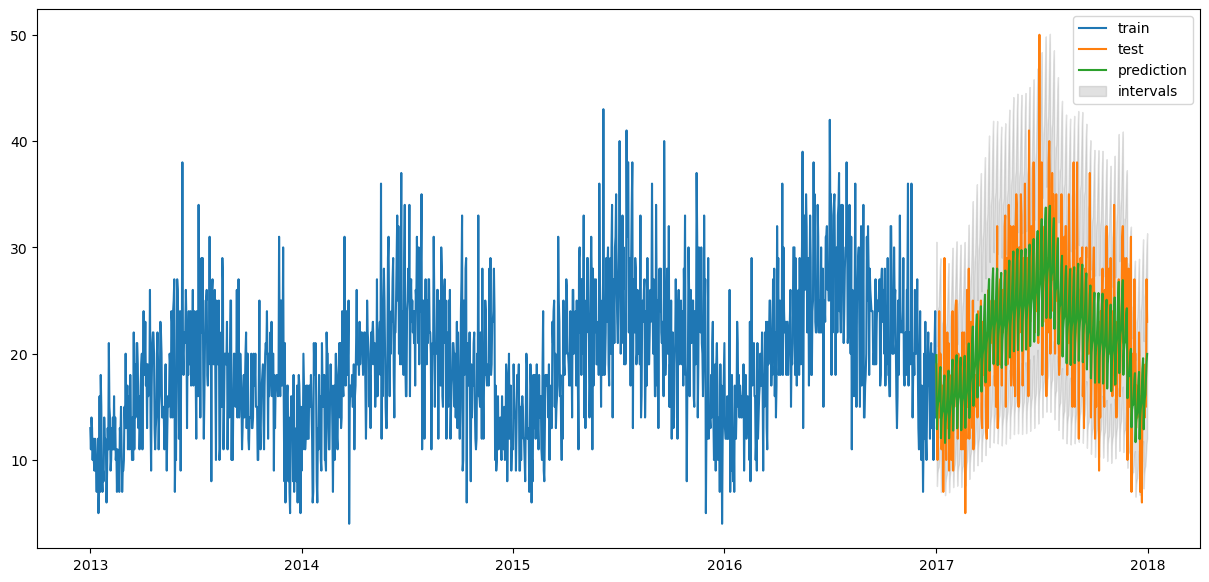

In [88]:
# Визуализация
plot_results(data_train, data_test, tbats_forecast_tuned, plot_conf_int=True,
             left_bound  = confidence_info_tuned['lower_bound'],
             right_bound = confidence_info_tuned['upper_bound'])

In [89]:
compare_table = add_method_comparison(
    'TBATS Tuned', 
    data_test, 
    tbats_forecast_tuned, 
    time_fit=time_fit,
    compare_table=compare_table
)
compare_table

,method,MSE,MAE,MAPE,time_fit
0,Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32
3,Prophet Tuned,32.255030,4.433706,19.942422,0.12
4,Auto arima model,70.529323,6.632215,28.845954,372.34
5,Auto arima model + exog,70.529323,6.632215,28.845954,366.78
6,Auto arima improved,62.968799,6.212377,28.091842,30.24
7,SARIMAX original,68.968723,6.599315,28.755754,42.97
8,SARIMAX + exog,28.371378,4.219990,22.401961,93.41
9,SARIMAX Tuned,23.408602,3.870457,19.882656,39.68


In [90]:
# print(best_tbats_model.summary())

### 7.3. TBATS. Сравнение всех вариантов

In [93]:
# Выведем сравнение всех вариантов Prophet
tbats_models_comparison = compare_table[compare_table['method'].str.contains('TBATS')]
tbats_models_comparison = tbats_models_comparison.sort_values('MAPE')

print("\nСравнение вариантов TBATS:")
tbats_models_comparison


Сравнение вариантов TBATS:


,method,MSE,MAE,MAPE,time_fit
11,TBATS Tuned,23.169422,3.812106,19.526897,155.04
10,TBATS model,64.837757,6.335531,27.126884,93.93


## 8. ИТОГО

todo:
- Опишите, что вы сделали в этой работе, какие параметры моделей подбирали и как.
- Сравните модели между собой и проанализируйте результаты.
- Выберите лучшую модель.

Метрика MAPE, которую нужно достичь (достаточно правильной настройки гиперпараметров моделей), должна быть менее 20%.

### 8.1. Финальная таблица

In [92]:
print('\nРезультаты всех моделей (сортировка по MAPE):\n')
compare_table.sort_values('MAPE', ascending=True)


Результаты всех моделей (сортировка по MAPE):



,method,MSE,MAE,MAPE,time_fit
11,TBATS Tuned,23.169422,3.812106,19.526897,155.04
9,SARIMAX Tuned,23.408602,3.870457,19.882656,39.68
3,Prophet Tuned,32.255030,4.433706,19.942422,0.12
2,Prophet + BoxCox,24.099394,3.986501,21.671746,0.32
0,Prophet,24.681231,4.032162,22.234017,0.76
8,SARIMAX + exog,28.371378,4.219990,22.401961,93.41
1,Prophet + Holidays,25.021806,4.068062,22.477414,0.32
10,TBATS model,64.837757,6.335531,27.126884,93.93
6,Auto arima improved,62.968799,6.212377,28.091842,30.24
7,SARIMAX original,68.968723,6.599315,28.755754,42.97


### 8.2. Визуализация результатов сравненения моделей

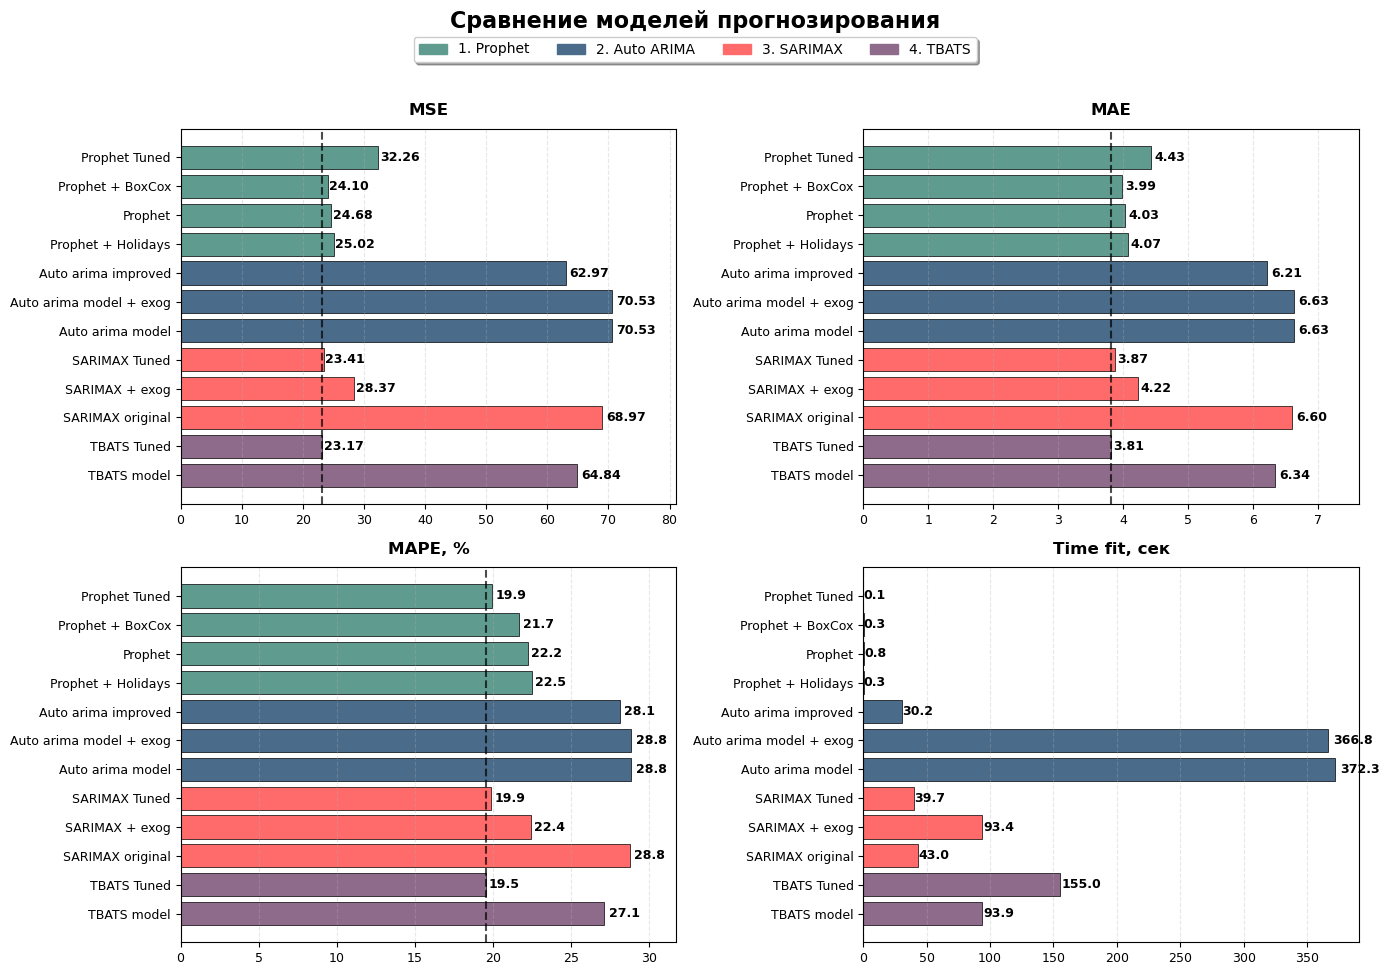


Датафрейм с группами и цветами:


,method,group,MSE,MAE,MAPE,time_fit
3,Prophet Tuned,1. Prophet,32.255030,4.433706,19.942422,0.12
2,Prophet + BoxCox,1. Prophet,24.099394,3.986501,21.671746,0.32
0,Prophet,1. Prophet,24.681231,4.032162,22.234017,0.76
1,Prophet + Holidays,1. Prophet,25.021806,4.068062,22.477414,0.32
6,Auto arima improved,2. Auto ARIMA,62.968799,6.212377,28.091842,30.24
4,Auto arima model,2. Auto ARIMA,70.529323,6.632215,28.845954,372.34
5,Auto arima model + exog,2. Auto ARIMA,70.529323,6.632215,28.845954,366.78
9,SARIMAX Tuned,3. SARIMAX,23.408602,3.870457,19.882656,39.68
8,SARIMAX + exog,3. SARIMAX,28.371378,4.219990,22.401961,93.41
7,SARIMAX original,3. SARIMAX,68.968723,6.599315,28.755754,42.97


In [118]:
import matplotlib.pyplot as plt
import numpy as np

# Создаем копию датафрейма для работы
df_plot = compare_table.copy()

# Определяем группы для каждой модели на основе названия
def assign_group(model_name):
    if 'Prophet' in model_name:
        return '1. Prophet'
    elif 'Auto arima' in model_name:
        return '2. Auto ARIMA'
    elif 'SARIMAX' in model_name:
        return '3. SARIMAX'
    elif 'TBATS' in model_name:
        return '4. TBATS'
    else:
        return '5. Other'

# Добавляем столбцы с группой и цветом
df_plot['group'] = df_plot['method'].apply(assign_group)

# Задаем цвета для каждой группы
group_colors = {
    '1. Prophet':    '#5F9B8E',   # Зеленый
    '2. Auto ARIMA': '#4A6B8A',   # Синий
    '3. SARIMAX':    '#FF6B6B',   # Красный
    '4. TBATS':      '#8E6B8A',   # Фиолетовый
}

# Добавляем столбец с цветом
df_plot['color'] = df_plot['group'].map(group_colors)

# Создаем сетку графиков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение моделей прогнозирования', fontsize=16, fontweight='bold', y=1.02)

# Метрики для графиков
metrics_list = ['MSE', 'MAE', 'MAPE', 'time_fit']
titles = ['MSE', 'MAE',  'MAPE, %', 'Time fit, сек']

for idx, (ax, metric, title) in enumerate(zip(axes.flat, metrics_list, titles)):
    # Сортируем датафрейм
    df_sorted = df_plot.sort_values(['group', 'MAPE'], ascending=[False, False])
    
    # Берем данные из отсортированного датафрейма
    model_names = df_sorted['method'].tolist()
    values = df_sorted[metric].tolist()
    colors_list = df_sorted['color'].tolist()
    
    # Находим минимальное значение для текущей метрики
    min_value = min(values)
    
    # Горизонтальные столбцы
    bars = ax.barh(model_names, values, color=colors_list, edgecolor='black', linewidth=0.5)
    
    # Добавляем вертикальную пунктирную линию минимального значения
    ax.axvline(x=min_value, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Подписи значений
    for bar, value in zip(bars, values):
        if metric == 'time_fit':
            label = f'{value:.1f}'
        elif metric == 'MAPE':
            label = f'{value:.1f}'
        else:
            label = f'{value:.2f}'
        
        # Размещаем текст справа от столбца
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=9, fontweight='bold')
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=9)
    
    # Сетка только по оси X
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Настраиваем отступы
    ax.set_xlim(left=0)
    max_val = max(values)
    if metric in ['MSE', 'MAE']:
        ax.set_xlim(right=max_val * 1.15)
    elif metric == 'MAPE':
        ax.set_xlim(right=max_val * 1.1)
    else:  # time_fit
        ax.set_xlim(right=max_val * 1.05)

# Добавляем легенду с цветами групп
legend_elements = [plt.Rectangle((0,0),1,1, color=color, label=group) for group, color in group_colors.items()]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, 1.0), frameon=True, fancybox=True, shadow=True)

# Настройка layout
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

# Показываем датафрейм с группами для проверки
print("\nДатафрейм с группами и цветами:")
df_plot[['method', 'group', 'MSE', 'MAE', 'MAPE', 'time_fit']].sort_values(['group', 'MAPE'], ascending=[True, True])

### 8.3. Общие итоги и выводы

#### 1. Что было сделано, какие параметры моделей подобраны

##### Prophet:
1. **Базовый Prophet** – модель с параметрами по умолчанию  
2. **Prophet + US holidays** – добавление праздников через `add_country_holidays('US')`  
3. **Prophet + BoxCox** – применение преобразования Бокса-Кокса для стабилизации дисперсии  
4. **Prophet с тонкой настройкой** – двухэтапный GridSearch:
   - Этап 1: подбор `growth`, `holidays_prior_scale`, `seasonality_mode`
   - Этап 2: уточнение `changepoint_prior_scale`, `seasonality_prior_scale`, `changepoint_range`

##### AutoARIMA:
- **Базовый auto_arima** – с автоматическим подбором параметров (`stepwise=True`)  
- **Auto_arima + exog** – с добавлением тригонометрических экзогенных переменных (`sin365`, `cos365`)  
- **Auto_arima улучшенный** – с полным перебором (`stepwise=False`) и расширенными экзогенными признаками:
  - (one-hot кодирование дней недели, месяцев, кварталов, выходных)

##### SARIMAX:
- **Базовый SARIMAX** – с параметрами, подобранными auto_arima  
- **SARIMAX + exog** – с добавлением тех же тригонометрических базовых экзогенных переменных, что и для модели auto_arima_exog
- **SARIMAX с подбором параметров** – ручной перебор `(p,d,q)` и `(P,D,Q,s)` с расширенным списом экзогенных переменных

##### TBATS:
- **Базовый TBATS** – с сезонностями `(7, 180)`  
- **TBATS с подбором параметров** – двухэтапный GridSearch:
  - Этап 1: перебор `use_box_cox`, `use_trend`, `use_damped_trend`
  - Этап 2: тестирование различных `seasonal_periods` с добавлением `use_arma_errors`

___
#### 2. Сравнение моделей между собой и анализ результатов

**Модели, достигшие целевого MAPE < 20%:**

1. **TBATS Tuned** (19.53%) – лучший результат, оптимальна для сложных сезонных паттернов  
2. **SARIMAX Tuned** (19.88%) – близкое качество при меньшем времени обучения  
3. **Prophet Tuned** (19.94%) – хороший баланс точности и скорости

**Модели, не достигшие целевого MAPE:**

- **AutoARIMA** (все варианты: 28.09–28.85%) – несмотря на полный перебор параметров и расширенные экзогенные признаки  
- Базовые версии **Prophet** (21.67–22.48%)  
- **SARIMAX** без подбора параметров (22.40–28.76%)

##### Замечания

1. **Тонкая настройка критична:** Все три лучшие модели прошли этап подбора гиперпараметров  
2. **Экзогенные переменные помогают:** SARIMAX с экзогенными признаками улучшила MAPE с 28.76% до 22.40%  
3. **Ограничения auto_arima:** Даже с полным перебором параметров и расширенными признаками, алгоритм не нашел оптимальную конфигурацию для этого ряда

___
#### 3. Выбор лучшей модели

**TBATS Tuned** показала наилучший результат (**MAPE = 19.53%**) и является оптимальным выбором для данного временного ряда, так как:

1. Специально разработана для работы с множественными сезонностями  
2. Автоматически подбирает параметры Box-Cox преобразования  
3. Учитывает сложные трендовые компоненты

**SARIMAX Tuned** имеет сопоставимое качество (**MAPE = 19.88%**) при значительно меньшем времени обучения (**39.7 сек против 155 сек** у TBATS), что может быть важно при ограниченных вычислительных ресурсах.

**Prophet Tuned** также показала хороший (**MAPE = 19.94%**) результат при минимальном времени обучения (**менее 1 сек**), что делает её практичным выбором для оперативного прогнозирования.